Unified + Separated Report — Baselines · BYOL · MoCo · TFT

## Cell 1 — Imports, canonical colours & order, helpers

In [1]:
import os, json, gc
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
%matplotlib inline 

SHOW_OUTPUT = True # TOGGLE: if True, y-axis direction is flipped (0 at top, 1 at bottom).
INVERT_Y = False

# OUTPUT DIRECTORIES
COMPARE_DIR = 'plots/compare'
SEP_DIR     = 'plots/separated'
for d in [COMPARE_DIR, SEP_DIR,
          f'{SEP_DIR}/baselines', f'{SEP_DIR}/ssl_byol', f'{SEP_DIR}/ssl_moco',
          f'{SEP_DIR}/ssl_compare', f'{SEP_DIR}/tft', f'{SEP_DIR}/attention',
          f'{SEP_DIR}/fewshot', f'{SEP_DIR}/per_class']:
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 160, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
})


# CANONICAL METHOD COLOURS

METHOD_COLORS = {
    'GCN':        '#7f7f7f',
    'GAT':        '#111111',
    'BYOL-probe': '#1f77b4',
    'MOCO-probe': '#2ca02c',
    'TFT-BYOL':   '#7e1919',
    'TFT-MOCO':   '#ff7f0e',
}
def _color(m): return METHOD_COLORS.get(m, '#999999')

METHOD_ORDER = ['GCN', 'GAT',
                'BYOL-probe', 'MOCO-probe',
                'TFT-BYOL', 'TFT-MOCO']

PHASE_COLORS = {
    'Baseline': '#666666', 'BYOL probe': '#1f77b4', 'MoCo probe': '#2ca02c',
    'TFT single': '#7e1919', 'TFT ensemble': '#ff7f0e',
}

# TOP-3 RANKING STYLE  (red = 1st, green = 2nd, blue = 3rd)

RANK_COLORS = ['red', 'green', 'blue']
RANK_MARKS  = ['\u00b9', '\u00b2', '\u00b3']  
RANK_TOP    = 3

def _rank_indices(vals, mode='max', top=RANK_TOP):
    """Return list of (index, rank) for the top-`top` finite entries of `vals`.
    mode='max' ranks larger-is-better; mode='min' ranks smaller-is-better.
    Ties are broken by ascending index so results are deterministic."""
    arr = np.asarray(vals, dtype=float)
    valid = [(i, float(v)) for i, v in enumerate(arr) if np.isfinite(v)]
    if mode == 'max':
        valid.sort(key=lambda t: (-t[1], t[0]))
    else:
        valid.sort(key=lambda t: (t[1], t[0]))
    return [(i, r) for r, (i, _) in enumerate(valid[:top])]

def _rank_suffix(rank):
    return RANK_MARKS[rank] if 0 <= rank < len(RANK_MARKS) else ''


# DATASETS

DATASETS  = ['gotham', 'nf_bot', 'nf_ton']
SSL_LIST  = ['byol', 'moco']
PHASES    = ['Baseline', 'BYOL probe', 'MoCo probe', 'TFT single', 'TFT ensemble']
DATA_DIRS = {
    'gotham':  'Gotham_processed_features_10s/graphs',
    'nf_bot':  'NFBoTIoT_v3_10s/graphs',
    'nf_ton':  'NFToNIoT_v3_10s/graphs',
}


# HELPERS

def _save(fig, name, folder=COMPARE_DIR):
    path = os.path.join(folder, name)
    fig.savefig(path, bbox_inches='tight')
    if SHOW_OUTPUT:
        plt.show()          # render inline in the notebook
    plt.close(fig)
    print(f"[save] {path}")

def _num(x, default=np.nan):
    try:
        v = float(x)
        return v if np.isfinite(v) else default
    except (TypeError, ValueError):
        return default

def _load_json(p):
    if p and os.path.isfile(p):
        try:
            with open(p) as f: return json.load(f)
        except Exception as e:
            print(f"[warn] {p}: {e}")
    return None

def _methods_in(df):
    present = set(df['method'].unique())
    return [m for m in METHOD_ORDER if m in present]

def _legend_for(methods, ax, **kw):
    handles = [Patch(facecolor=_color(m), edgecolor='black', label=m) for m in methods]
    ax.legend(handles=handles, **kw)

def _rank_legend(ax, loc='upper right', fontsize=7):
    """Small explanatory legend: red=1st, green=2nd, blue=3rd."""
    handles = [Patch(facecolor='white', edgecolor=RANK_COLORS[i], linewidth=2,
                     label=f'rank {i+1}') for i in range(RANK_TOP)]
    leg = ax.legend(handles=handles, loc=loc, fontsize=fontsize,
                    framealpha=0.9, title='top-3', title_fontsize=fontsize)
    ax.add_artist(leg)


# LOG-SCALE ERROR-RATE STYLING  (raw values, not complements)

ERR_FLOOR = 1e-5   # any raw error below this is clipped for the log axis
ERR_TOP   = 1.05   # a hair above 1.0 so a 1.0 error is still visible
ERR_GRID  = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0]

def _log_error_axis(ax):
    """Configure an axis to show raw error rates on a log scale, 0-safe."""
    ax.set_yscale('log')
    if INVERT_Y:
        ax.set_ylim(ERR_TOP, ERR_FLOOR)
    else:
        ax.set_ylim(ERR_FLOOR, ERR_TOP)
    for y in ERR_GRID:
        ax.axhline(y, color='grey', ls=':', lw=0.6, alpha=0.55, zorder=0)
    ax.set_yticks(ERR_GRID)
    ax.set_yticklabels([f"{y:g}" for y in ERR_GRID], fontsize=7)

def _place_err_label(ax, bar, raw_value, invert_y, suffix=''):
    """Put the numeric label just outside the tip of a log-scale bar."""
    if not np.isfinite(raw_value): return
    y = max(raw_value, ERR_FLOOR)
    txt = f"{raw_value:.4f}{suffix}"
    if invert_y:
        ax.text(bar.get_x() + bar.get_width()/2, y*0.85, txt,
                ha='center', va='top', fontsize=7, color='black')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, y*1.15, txt,
                ha='center', va='bottom', fontsize=7, color='black')


# Table formatting

def _fmt_cell(v, is_best, decimals=4):
    if not np.isfinite(v): return '  --  '
    s = f"{v:.{decimals}f}"
    return s + ('*' if is_best else ' ')

def _mark_best(df, cols, directions, scope='dataset', decimals=4):
    out = df.copy()
    for c in cols: out[c] = out[c].astype(object)
    win = {c: set() for c in cols}
    if scope == 'dataset':
        for c in cols:
            for _, g in out.groupby('dataset', sort=False):
                vals = pd.to_numeric(g[c], errors='coerce')
                if vals.notna().sum() == 0: continue
                i = vals.idxmax() if directions[c] == 'max' else vals.idxmin()
                win[c].add(i)
    else:
        for c in cols:
            vals = pd.to_numeric(out[c], errors='coerce')
            if vals.notna().sum() == 0: continue
            i = vals.idxmax() if directions[c] == 'max' else vals.idxmin()
            win[c].add(i)
    for c in cols:
        out[c] = [_fmt_cell(pd.to_numeric(v, errors='coerce'), i in win[c], decimals)
                  for i, v in zip(out.index, out[c])]
    return out

DIRS = {'ROC':'max','PR':'max','F1':'max','FPR':'min','FNR':'min',
        'mF1_bin':'max','mF1_multi':'max'}

print("Setup ready.")
print(f"  SHOW_OUTPUT = {SHOW_OUTPUT}   (True = render figures inline too)")
print(f"  INVERT_Y    = {INVERT_Y}   (True = 0 at top, 1 at bottom)")
print(f"  ERR_FLOOR   = {ERR_FLOOR}")
print(f"  ERR_TOP     = {ERR_TOP}")
print(f"  RANK_TOP    = {RANK_TOP}   (edge colours: {RANK_COLORS})")

Setup ready.
  SHOW_OUTPUT = True   (True = render figures inline too)
  INVERT_Y    = False   (True = 0 at top, 1 at bottom)
  ERR_FLOOR   = 1e-05
  ERR_TOP     = 1.05
  RANK_TOP    = 3   (edge colours: ['red', 'green', 'blue'])


## Cell 2 — Load every artefact into one long-form DataFrame

In [ ]:
rows = []

# ---- Baselines ----
BASELINE_CACHE_ROOT = 'baseline_checkpoints_tftparity'
_baseline_json = os.path.join(BASELINE_CACHE_ROOT, 'baseline_benchmark.json')

base = _load_json(_baseline_json) or {}
if not base:
    _legacy = os.path.join('baseline_checkpoints', 'baseline_benchmark.json')
    if os.path.isfile(_legacy):
        print(f"[warn] {_baseline_json} not found; falling back to {_legacy}")
        base = _load_json(_legacy) or {}
    else:
        print(f"[warn] no baseline cache found at {_baseline_json}")
else:
    print(f"[baseline cache] loaded {_baseline_json}")

for ds, per_m in base.items():
    for mth, m in per_m.items():
        if not isinstance(m, dict) or m.get('status', 'done') != 'done': continue
        rows.append(dict(
            phase='Baseline', dataset=ds, method=mth.upper(),
            ROC=_num(m.get('ROC')), PR=_num(m.get('PR')), F1=_num(m.get('F1')),
            FPR=_num(m.get('FPR')), FNR=_num(m.get('FNR')),
            mF1_bin=_num(m.get('mF1_bin')), mF1_multi=_num(m.get('mF1_multi')),
        ))

# ---- SSL probes ----
for ssl, fname, phase_name in [('byol', 'pure_byol_ssl_summary.json', 'BYOL probe'),
                                ('moco', 'pure_moco_ssl_summary.json', 'MoCo probe')]:
    d = _load_json(fname) or {}
    for ds, r in d.items():
        if not isinstance(r, dict) or 'error' in r: continue
        rows.append(dict(
            phase=phase_name, dataset=ds, method=f"{ssl.upper()}-probe",
            ROC=_num(r.get('test_roc_auc')), PR=_num(r.get('test_pr_auc')),
            F1=_num(r.get('test_f1_binary', r.get('test_f1'))),
            FPR=_num(r.get('test_fpr')), FNR=_num(r.get('test_fnr')),
            mF1_bin=_num(r.get('test_macro_f1')), mF1_multi=np.nan,
        ))

# ---- TFT single + ensemble ----
raw = _load_json('phase3_all_results_raw.json') or {}
if raw and not set(raw.keys()).issubset({'byol', 'moco'}):
    by_ssl = {'byol': {}, 'moco': {}}
    for ds, per in raw.items():
        if isinstance(per, dict):
            for ssl, r in per.items():
                by_ssl.setdefault(ssl.lower(), {})[ds] = r
    raw = by_ssl

for ssl, per_ds in raw.items():
    for ds, r in per_ds.items():
        if not isinstance(r, dict) or '_skipped_no_ssl' in r or 'error' in r:
            continue
        b = r.get('main_run', {}) or {}
        rows.append(dict(
            phase='TFT single', dataset=ds, method=f"TFT-{ssl.upper()}",
            ROC=_num(b.get('binary_test_roc')), PR=_num(b.get('binary_test_pr')),
            F1=_num(b.get('binary_test_f1')),
            FPR=_num(b.get('binary_test_fpr')), FNR=_num(b.get('binary_test_fnr')),
            mF1_bin=np.nan,
            mF1_multi=_num(b.get('multiclass_test_macro_f1',
                                b.get('multiclass_test_macro_f1_merged')))
        ))
        e = r.get('ensemble', {}) or {}
        rows.append(dict(
            phase='TFT ensemble', dataset=ds, method=f"TFT-{ssl.upper()}",
            ROC=_num(e.get('binary_test_roc')), PR=_num(e.get('binary_test_pr')),
            F1=_num(e.get('binary_test_f1')),
            FPR=_num(e.get('binary_test_fpr')), FNR=_num(e.get('binary_test_fnr')),
            mF1_bin=np.nan,
            mF1_multi=_num(e.get('multiclass_test_macro_f1',
                                e.get('multiclass_test_macro_f1_merged')))
        ))

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No results found — run the four notebooks first.")
DATASETS = [d for d in DATASETS if d in df['dataset'].unique()]
print(f"[load] {len(df)} rows | datasets={DATASETS}")
print(f"[load] methods in canonical order: {_methods_in(df)}")
print(df.head(6).to_string(index=False))

[baseline cache] loaded baseline_checkpoints_tftparity\baseline_benchmark.json
[load] 24 rows | datasets=['gotham', 'nf_bot', 'nf_ton']
[load] methods in canonical order: ['GCN', 'GAT', 'BYOL-probe', 'MOCO-probe', 'TFT-BYOL', 'TFT-MOCO']
   phase dataset method      ROC       PR       F1      FPR      FNR  mF1_bin  mF1_multi
Baseline  gotham    GCN 0.650498 0.481840 0.356436 0.020595 0.770701 0.612295   0.071196
Baseline  gotham    GAT 0.964145 0.958312 0.878893 0.011442 0.191083 0.919980   0.076663
Baseline  nf_ton    GCN 0.428461 0.832342 0.948398 0.782609 0.006755 0.645432   0.024417
Baseline  nf_ton    GAT 0.605062 0.860154 0.950927 0.641739 0.018239 0.714443   0.017292
Baseline  nf_bot    GCN 0.980561 0.996762 0.956284 0.006452 0.082809 0.875049   0.191010
Baseline  nf_bot    GAT 0.968067 0.994760 0.964592 0.070968 0.057652 0.889076   0.187029


## Cell 3 — Unified tables (best per dataset marked with `*`)

In [3]:
print("=" * 150)
print("TABLE A · BINARY HEADLINE — * = best per dataset  (ROC/PR/F1 ↑; FPR/FNR ↓)")
print("=" * 150)
a = (df[['dataset', 'method', 'phase', 'ROC', 'PR', 'F1', 'FPR', 'FNR']]
       .sort_values(['dataset', 'phase', 'method']).reset_index(drop=True))
a = _mark_best(a, ['ROC', 'PR', 'F1', 'FPR', 'FNR'], DIRS)
print(a.to_string(index=False))

print("\n" + "=" * 150)
print("TABLE B · MULTICLASS MACRO-F1")
print("=" * 150)
b = df.dropna(subset=['mF1_multi'])
if b.empty:
    print("  (no multiclass rows)")
else:
    b = (b[['dataset', 'method', 'phase', 'mF1_multi', 'F1', 'ROC']]
           .sort_values(['dataset', 'phase', 'method']).reset_index(drop=True))
    b = _mark_best(b, ['mF1_multi', 'F1', 'ROC'], DIRS)
    print(b.to_string(index=False))

print("\n" + "=" * 150)
print("TABLE C · WINNER PER DATASET (best ROC across every method & phase)")
print("=" * 150)
win_rows = []
for ds, g in df.groupby('dataset'):
    def _best(col):
        s = g.dropna(subset=[col])
        return None if s.empty else s.loc[s[col].idxmax()]
    w_roc = _best('ROC'); w_f1 = _best('F1')
    gm = g.dropna(subset=['mF1_multi'])
    w_mf1 = None if gm.empty else gm.loc[gm['mF1_multi'].idxmax()]
    win_rows.append({
        'dataset': ds,
        ' ROC': f"{w_roc['ROC']:.4f}  {w_roc['method']} ({w_roc['phase']})" if w_roc is not None else '--',
        ' F1':  f"{w_f1['F1']:.4f}  {w_f1['method']} ({w_f1['phase']})" if w_f1 is not None else '--',
        ' mF1': f"{w_mf1['mF1_multi']:.4f}  {w_mf1['method']} ({w_mf1['phase']})" if w_mf1 is not None else '--',
    })
win = pd.DataFrame(win_rows)
win.to_csv(os.path.join(COMPARE_DIR, 'winner_per_dataset.csv'), index=False)
print(win.to_string(index=False))

TABLE A · BINARY HEADLINE — * = best per dataset  (ROC/PR/F1 ↑; FPR/FNR ↓)
dataset     method        phase     ROC      PR      F1     FPR     FNR
 gotham BYOL-probe   BYOL probe 0.9913  0.9584  0.9716  0.0137  0.0191 
 gotham        GAT     Baseline 0.9641  0.9583  0.8789  0.0114* 0.1911 
 gotham        GCN     Baseline 0.6505  0.4818  0.3564  0.0206  0.7707 
 gotham MOCO-probe   MoCo probe 0.9935* 0.9745  0.9716  0.0137  0.0191 
 gotham   TFT-BYOL TFT ensemble 0.9921  0.9798* 0.9618  0.0226  0.0308 
 gotham   TFT-MOCO TFT ensemble 0.9899  0.9592  0.9697  0.0226  0.0154*
 gotham   TFT-BYOL   TFT single 0.9882  0.9594  0.9618  0.0226  0.0308 
 gotham   TFT-MOCO   TFT single 0.9899  0.9567  0.9771* 0.0150  0.0154 
 nf_bot BYOL-probe   BYOL probe 0.8637  0.9745  0.9383  0.4516  0.0514 
 nf_bot        GAT     Baseline 0.9681  0.9948  0.9646  0.0710  0.0577 
 nf_bot        GCN     Baseline 0.9806  0.9968  0.9563  0.0065* 0.0828 
 nf_bot MOCO-probe   MoCo probe 0.8209  0.9658  0.9058  0.400

## Cell 4 — UNIFIED plots → `plots/compare/`

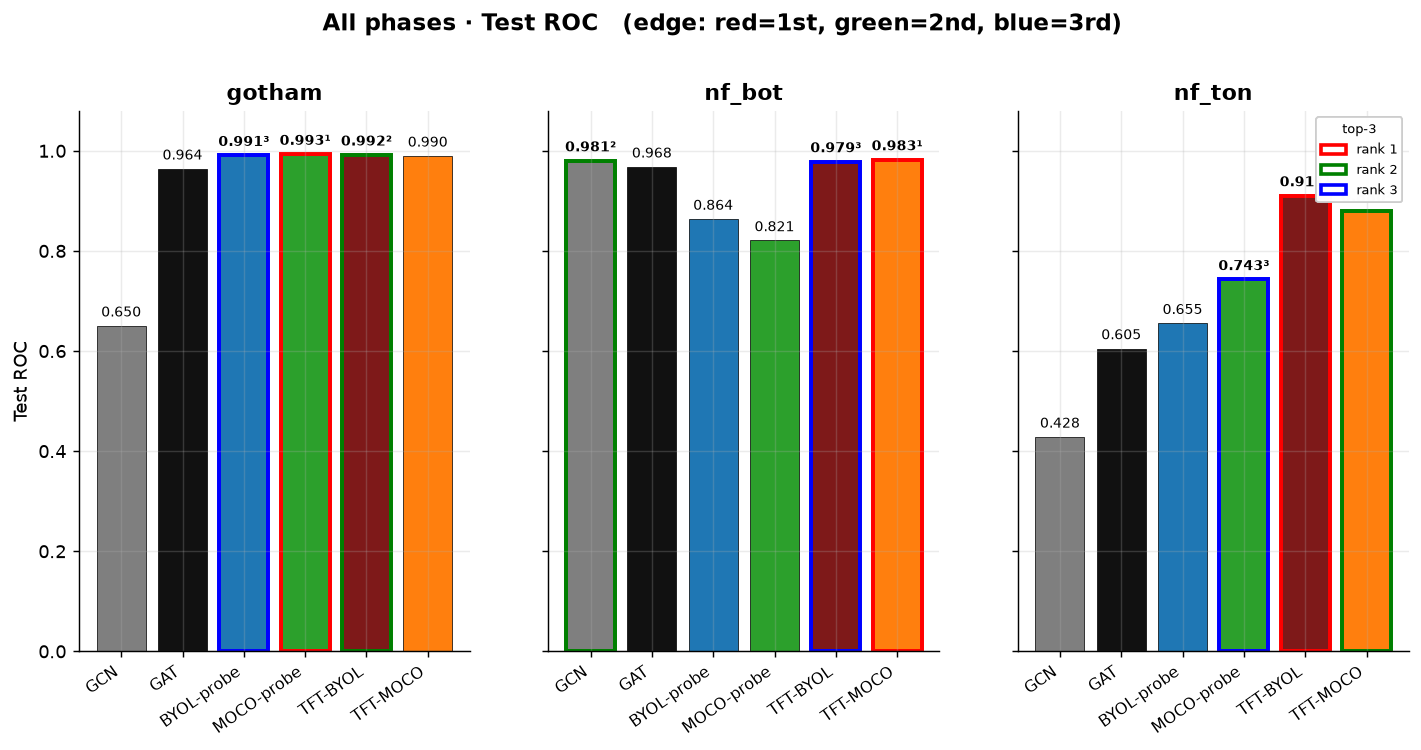

[save] plots/compare\01_headline_ROC.png


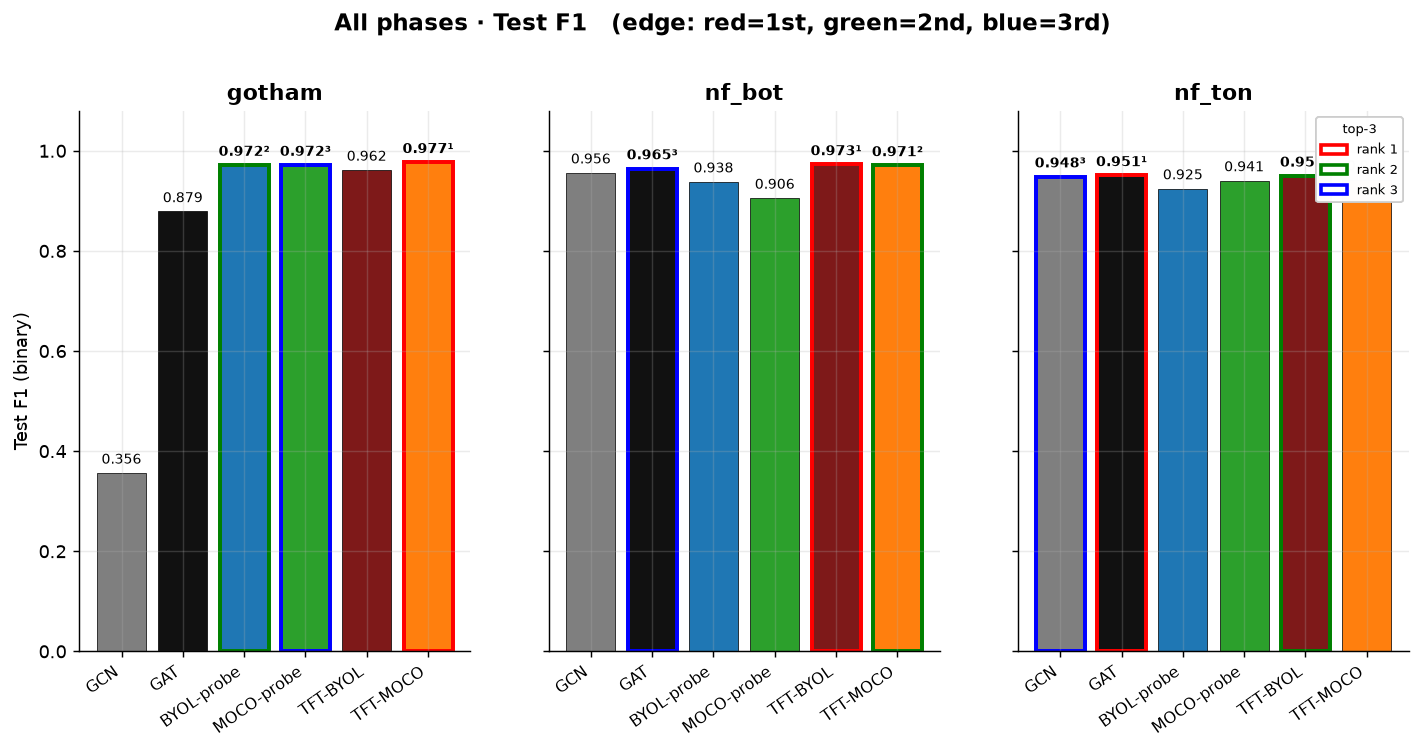

[save] plots/compare\02_headline_F1.png


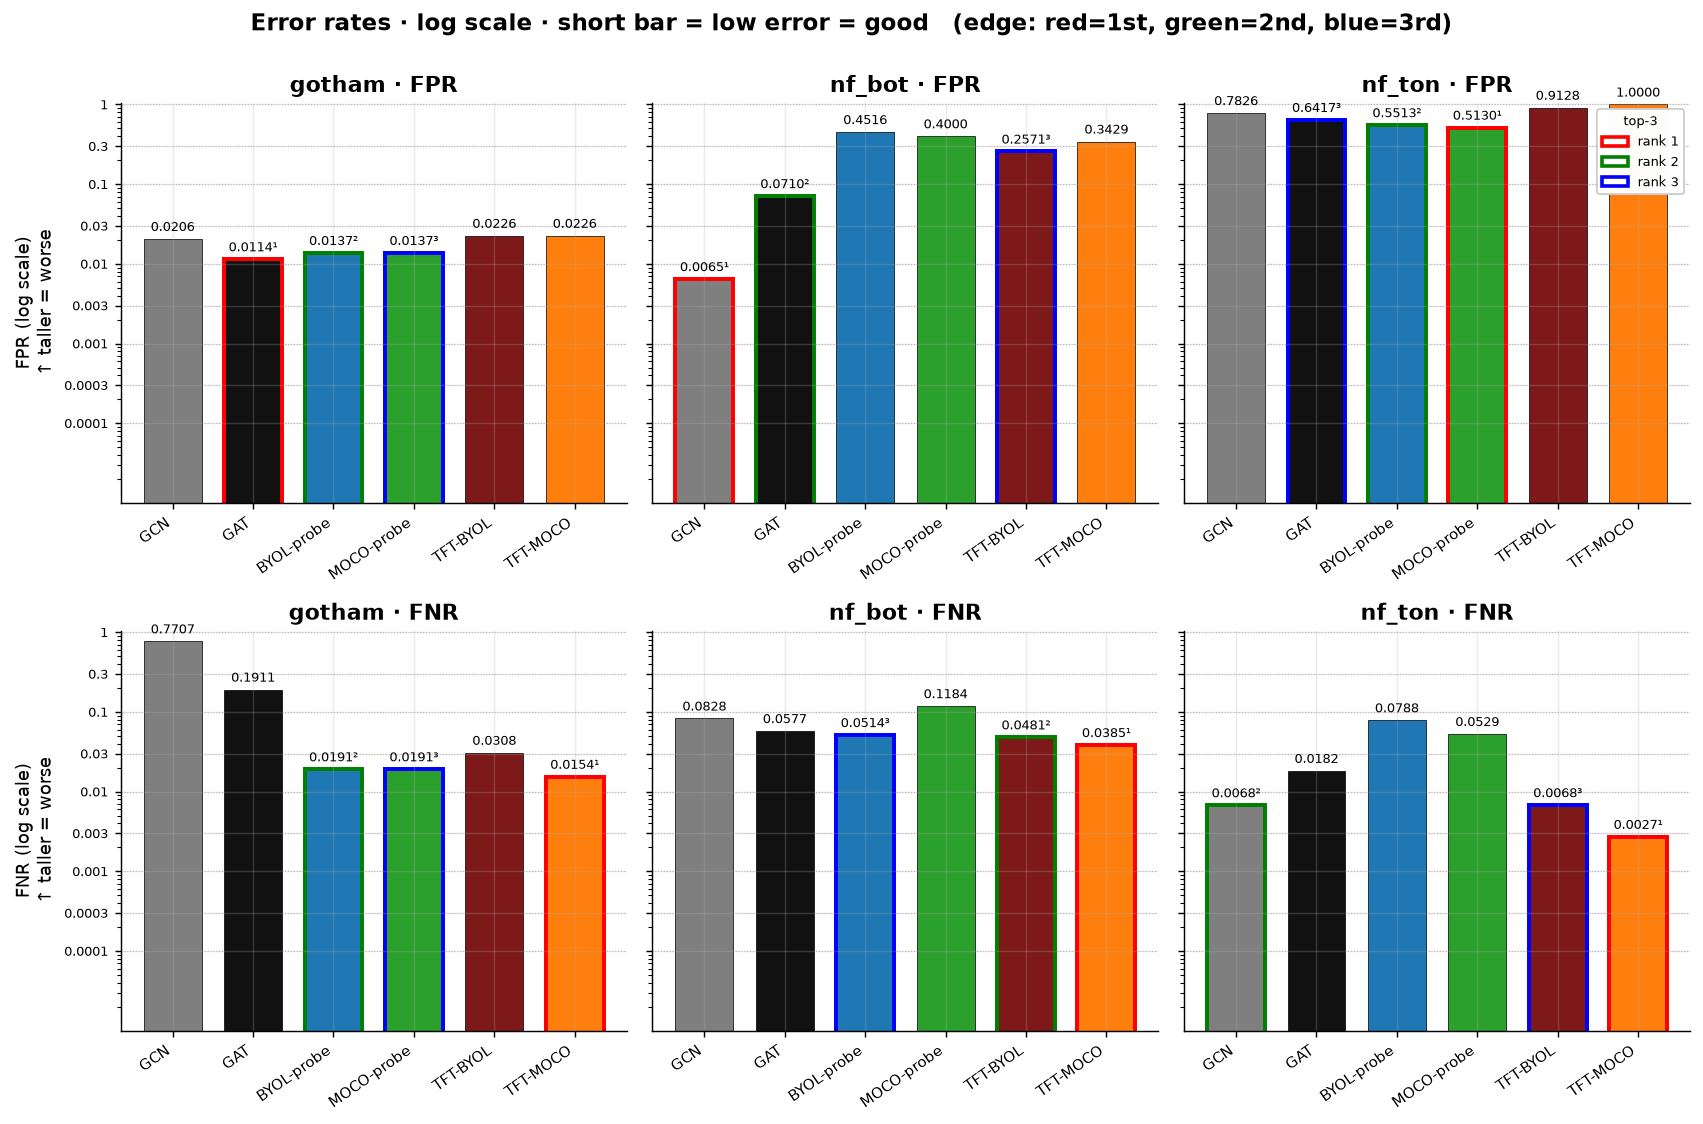

[save] plots/compare\03_error_rates.png


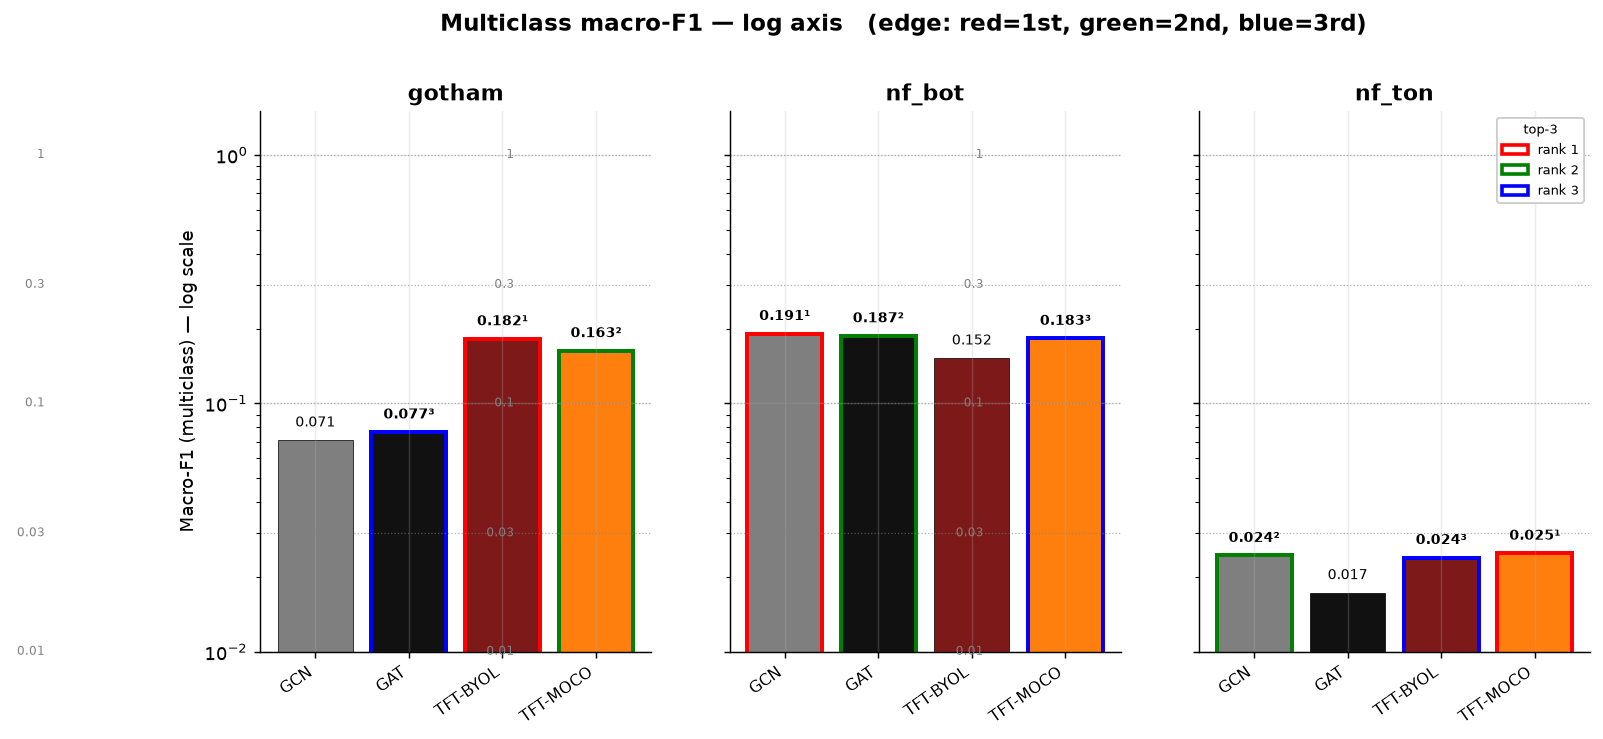

[save] plots/compare\04_macroF1_multi.png


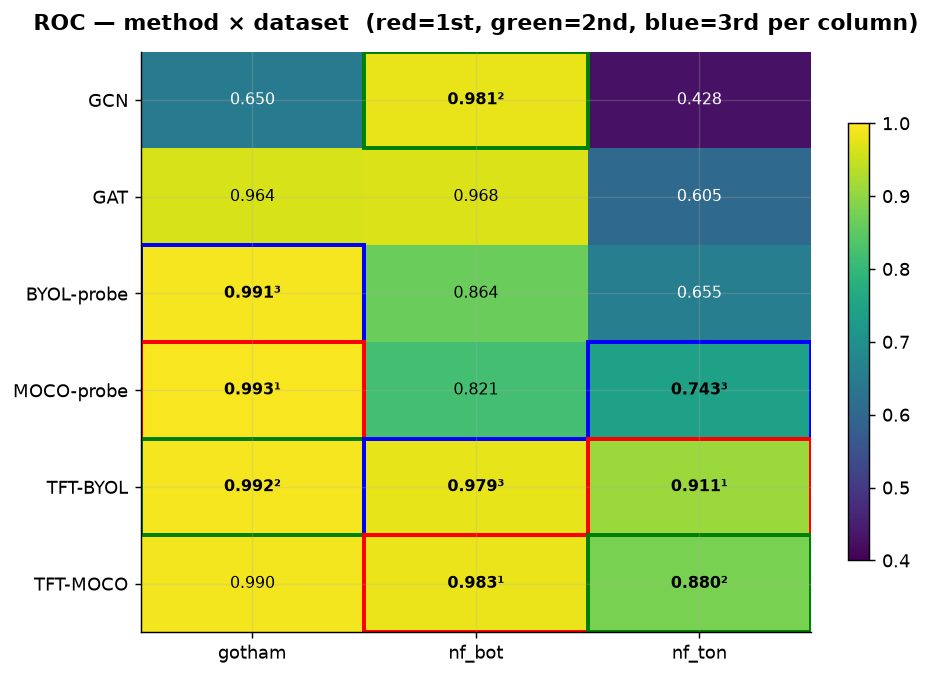

[save] plots/compare\05_heatmap_ROC.png


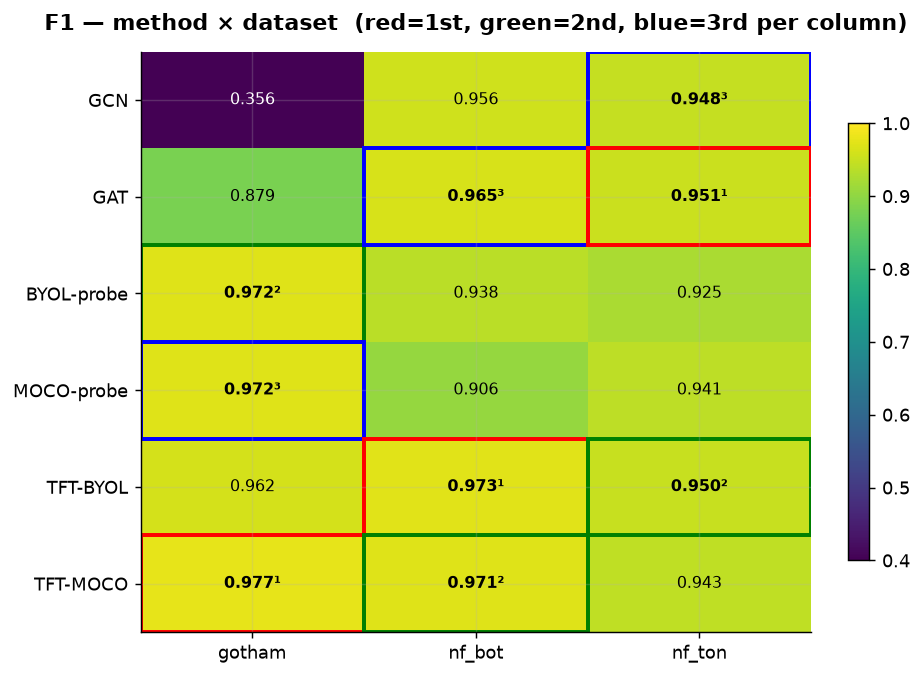

[save] plots/compare\06_heatmap_F1.png


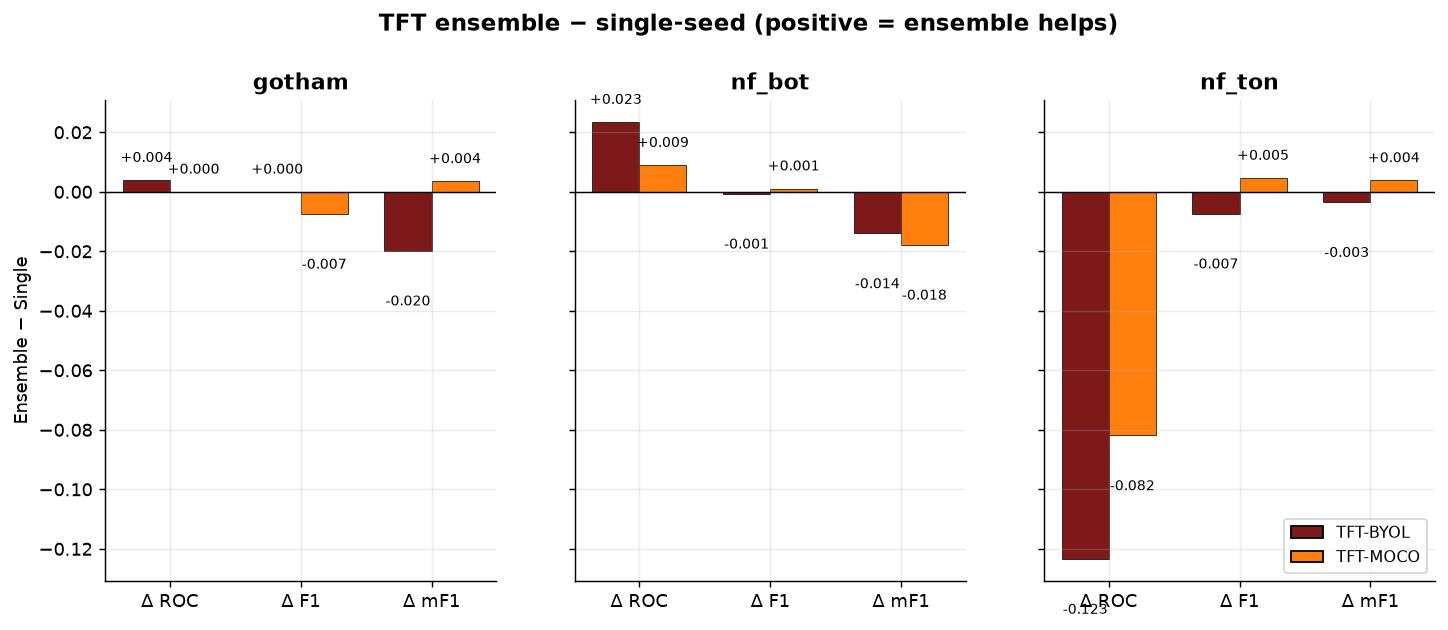

[save] plots/compare\07_ensemble_vs_single.png


In [12]:
def unified_grouped(metric, fname, ylabel, title, ylim=(0, 1.08)):
    methods = _methods_in(df)
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.4*len(DATASETS), 5.4), sharey=True)
    if len(DATASETS) == 1: axes = [axes]
    x = np.arange(len(methods))
    for ax, ds in zip(axes, DATASETS):
        sub = df[df['dataset'] == ds]
        vals = [sub[sub['method']==m][metric].max() for m in methods]
        cols = [_color(m) for m in methods]
        bars = ax.bar(x, vals, color=cols, edgecolor='black', linewidth=0.4)
        rank_of = dict(_rank_indices(vals, 'max'))          # top-3
        for i, (b, v) in enumerate(zip(bars, vals)):
            if np.isfinite(v):
                suffix = _rank_suffix(rank_of[i]) if i in rank_of else ''
                ax.text(b.get_x()+b.get_width()/2, v+0.012,
                        f"{v:.3f}{suffix}",
                        ha='center', va='bottom', fontsize=7.5,
                        fontweight='bold' if i in rank_of else 'normal')
            if i in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[i]])
                b.set_linewidth(2.2)
        ax.set_xticks(x); ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
        ax.set_title(ds); ax.set_ylim(*ylim)
    axes[0].set_ylabel(ylabel)
    _legend_for(methods, axes[-1], loc='lower right', fontsize=8, framealpha=0.9)
    _rank_legend(axes[-1], loc='upper right')
    fig.suptitle(f'{title}   (edge: red=1st, green=2nd, blue=3rd)',
                 y=1.02, fontsize=13, fontweight='bold')
    _save(fig, fname, COMPARE_DIR)

unified_grouped('ROC', '01_headline_ROC.png', 'Test ROC', 'All phases · Test ROC')
unified_grouped('F1',  '02_headline_F1.png',  'Test F1 (binary)', 'All phases · Test F1')


# ERROR RATES  — raw values, LOG y-axis, one row per metric
#   short bar = low error = GOOD.  INVERT_Y toggles the direction.

methods = _methods_in(df)
fig, axes = plt.subplots(2, len(DATASETS),
                         figsize=(4.4*len(DATASETS), 8.6), sharey=True)
if len(DATASETS) == 1: axes = np.array([[axes[0]], [axes[1]]])
x = np.arange(len(methods)); w = 0.72

for col, ds in enumerate(DATASETS):
    sub = df[df['dataset'] == ds]
    for row, metric in enumerate(['FPR', 'FNR']):
        ax = axes[row, col]
        vals = np.array([sub[sub['method']==m][metric].max() for m in methods], float)
        plot_vals = np.where(np.isfinite(vals),
                             np.clip(vals, ERR_FLOOR, ERR_TOP),
                             np.nan)
        cols = [_color(m) for m in methods]
        bars = ax.bar(x, plot_vals, w, color=cols,
                      edgecolor='black', linewidth=0.4)
        rank_of = dict(_rank_indices(vals, 'min'))          # lowest error = 1st
        for i, (b, v) in enumerate(zip(bars, vals)):
            suffix = _rank_suffix(rank_of[i]) if i in rank_of else ''
            _place_err_label(ax, b, v, INVERT_Y, suffix=suffix)
            if i in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[i]])
                b.set_linewidth(2.2)
        _log_error_axis(ax)
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=8.5)
        ax.set_title(f"{ds} · {metric}")
        if col == 0:
            direction = "↑ taller = worse" if not INVERT_Y else "↑ taller = worse"
            ax.set_ylabel(f"{metric} (log scale)\n{direction}")

_rank_legend(axes[0, -1], loc='upper right')
note = ("short bar = low error = good" if not INVERT_Y
        else "axis inverted: 0 near top, 1 at bottom")
fig.suptitle(f'Error rates · log scale · {note}   (edge: red=1st, green=2nd, blue=3rd)',
             y=1.00, fontsize=13, fontweight='bold')
plt.tight_layout()
_save(fig, '03_error_rates.png', COMPARE_DIR)


# MACRO-F1 on a LOG axis

sub = df.dropna(subset=['mF1_multi'])
if not sub.empty:
    methods = [m for m in METHOD_ORDER if m in sub['method'].unique()]
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.4*len(DATASETS), 5.4), sharey=True)
    if len(DATASETS) == 1: axes = [axes]
    x = np.arange(len(methods))
    for ax, ds in zip(axes, DATASETS):
        s = sub[sub['dataset'] == ds]
        vals = [s[s['method']==m]['mF1_multi'].max() for m in methods]
        cols = [_color(m) for m in methods]
        bars = ax.bar(x, vals, color=cols, edgecolor='black', linewidth=0.4)
        rank_of = dict(_rank_indices(vals, 'max'))
        for i, (b, v) in enumerate(zip(bars, vals)):
            if np.isfinite(v):
                suffix = _rank_suffix(rank_of[i]) if i in rank_of else ''
                ax.text(b.get_x()+b.get_width()/2, v*1.10,
                        f"{v:.3f}{suffix}",
                        ha='center', va='bottom', fontsize=7.5,
                        fontweight='bold' if i in rank_of else 'normal')
            if i in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[i]])
                b.set_linewidth(2.2)
        ax.set_xticks(x); ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
        ax.set_title(ds)
        ax.set_yscale('log'); ax.set_ylim(0.01, 1.5)
        for y in [0.01, 0.03, 0.10, 0.30, 1.00]:
            ax.axhline(y, color='grey', ls=':', lw=0.7, alpha=0.6)
            ax.text(-0.55, y, f" {y:g}", fontsize=6.5, va='center',
                    ha='right', color='grey', transform=ax.get_yaxis_transform())
    axes[0].set_ylabel('Macro-F1 (multiclass) — log scale')
    _legend_for(methods, axes[-1], loc='lower right', fontsize=8, framealpha=0.9)
    _rank_legend(axes[-1], loc='upper right')
    fig.suptitle('Multiclass macro-F1 — log axis   (edge: red=1st, green=2nd, blue=3rd)',
                 y=1.02, fontsize=13, fontweight='bold')
    _save(fig, '04_macroF1_multi.png', COMPARE_DIR)


# HEATMAPS

def _heatmap(metric, fname, cmap='viridis', vmin=0.4, vmax=1.0):
    piv = df.pivot_table(index='method', columns='dataset', values=metric, aggfunc='max')
    piv = piv.reindex(index=[m for m in METHOD_ORDER if m in piv.index])
    piv = piv.reindex(columns=[d for d in DATASETS if d in piv.columns])
    if piv.empty: return
    fig, ax = plt.subplots(figsize=(1.4*piv.shape[1]+3, 0.55*piv.shape[0]+2.0))
    im = ax.imshow(piv.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
    for j in range(piv.shape[1]):
        col_vals = piv.values[:, j]
        rank_of = dict(_rank_indices(col_vals, 'max'))       # top-3 per column
        for i in range(piv.shape[0]):
            v = col_vals[i]
            if not np.isfinite(v): continue
            suffix = _rank_suffix(rank_of[i]) if i in rank_of else ''
            ax.text(j, i, f"{v:.3f}{suffix}",
                    ha='center', va='center',
                    color='white' if v < (vmin + 0.55*(vmax-vmin)) else 'black',
                    fontsize=9, fontweight='bold' if i in rank_of else 'normal')
            if i in rank_of:
                ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1,
                                       fill=False,
                                       edgecolor=RANK_COLORS[rank_of[i]], lw=2.2))
    ax.set_title(f'{metric} — method × dataset  (red=1st, green=2nd, blue=3rd per column)',
                 pad=12)
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    _save(fig, fname, COMPARE_DIR)

_heatmap('ROC', '05_heatmap_ROC.png')
_heatmap('F1',  '06_heatmap_F1.png')


# TFT ensemble vs single

tft_rows = df[df['phase'].isin(['TFT single','TFT ensemble'])]
if not tft_rows.empty:
    piv = tft_rows.pivot_table(index=['dataset','method'], columns='phase',
                                values=['ROC','F1','mF1_multi'], aggfunc='first')
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.4*len(DATASETS), 4.8), sharey=True)
    if len(DATASETS) == 1: axes = [axes]
    x = np.arange(3); w = 0.36; labels = ['Δ ROC','Δ F1','Δ mF1']
    tft_methods = ['TFT-BYOL', 'TFT-MOCO']
    for ax, ds in zip(axes, DATASETS):
        rows_d = piv.loc[ds] if ds in piv.index.get_level_values(0) else None
        if rows_d is None:
            ax.axis('off'); continue
        for j, m in enumerate(tft_methods):
            if m not in rows_d.index: continue
            r = rows_d.loc[m]
            vals = [r.get(('ROC','TFT ensemble'), np.nan) - r.get(('ROC','TFT single'), np.nan),
                    r.get(('F1','TFT ensemble'),  np.nan) - r.get(('F1','TFT single'),  np.nan),
                    r.get(('mF1_multi','TFT ensemble'), np.nan) - r.get(('mF1_multi','TFT single'), np.nan)]
            off = -w/2 if j == 0 else w/2
            bars = ax.bar(x + off, vals, w, label=m, color=_color(m),
                          edgecolor='black', linewidth=0.4)
            for b, v in zip(bars, vals):
                if np.isfinite(v):
                    ax.text(b.get_x()+b.get_width()/2, v + (0.005 if v>=0 else -0.015),
                            f"{v:+.3f}", ha='center',
                            va='bottom' if v>=0 else 'top', fontsize=7.5)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_title(ds)
    axes[0].set_ylabel('Ensemble − Single')
    _legend_for(tft_methods, axes[-1], loc='lower right', fontsize=9)
    fig.suptitle('TFT ensemble − single-seed (positive = ensemble helps)',
                 y=1.02, fontsize=13, fontweight='bold')
    _save(fig, '07_ensemble_vs_single.png', COMPARE_DIR)

## Cell 5 — SEPARATED · Baselines only → `plots/separated/baselines/`

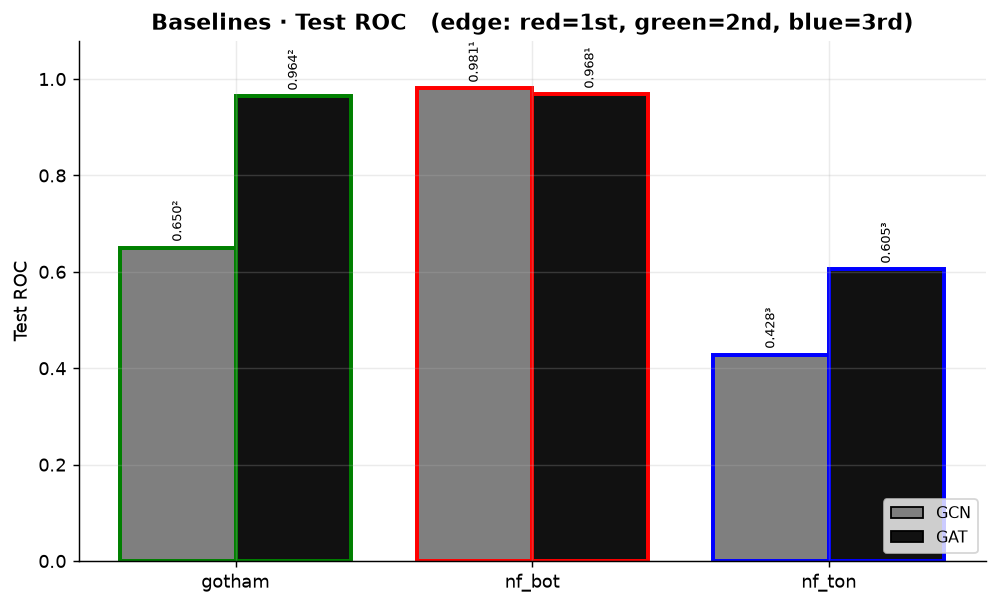

[save] plots/separated/baselines\roc_per_dataset.png


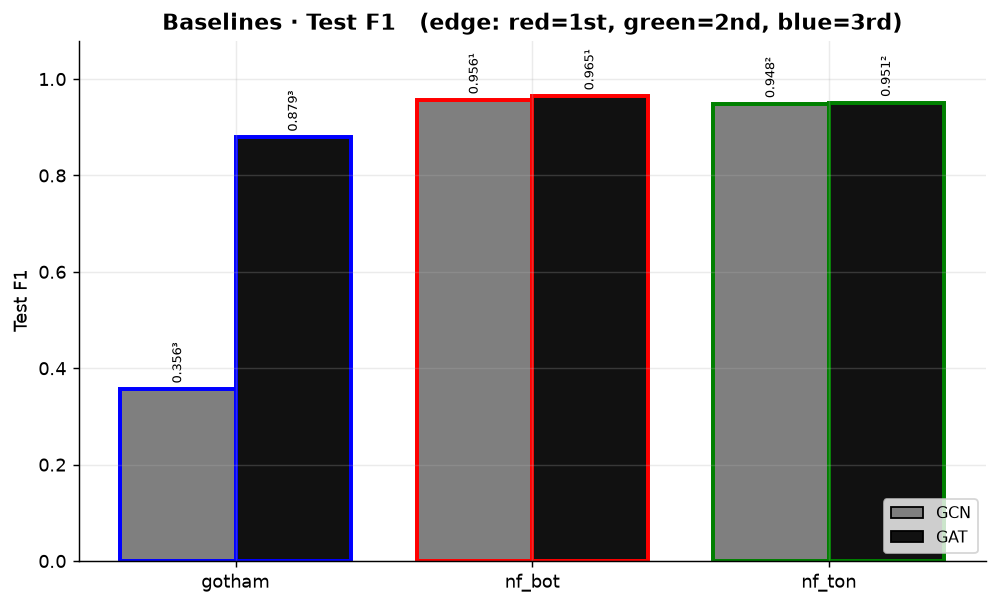

[save] plots/separated/baselines\f1_per_dataset.png


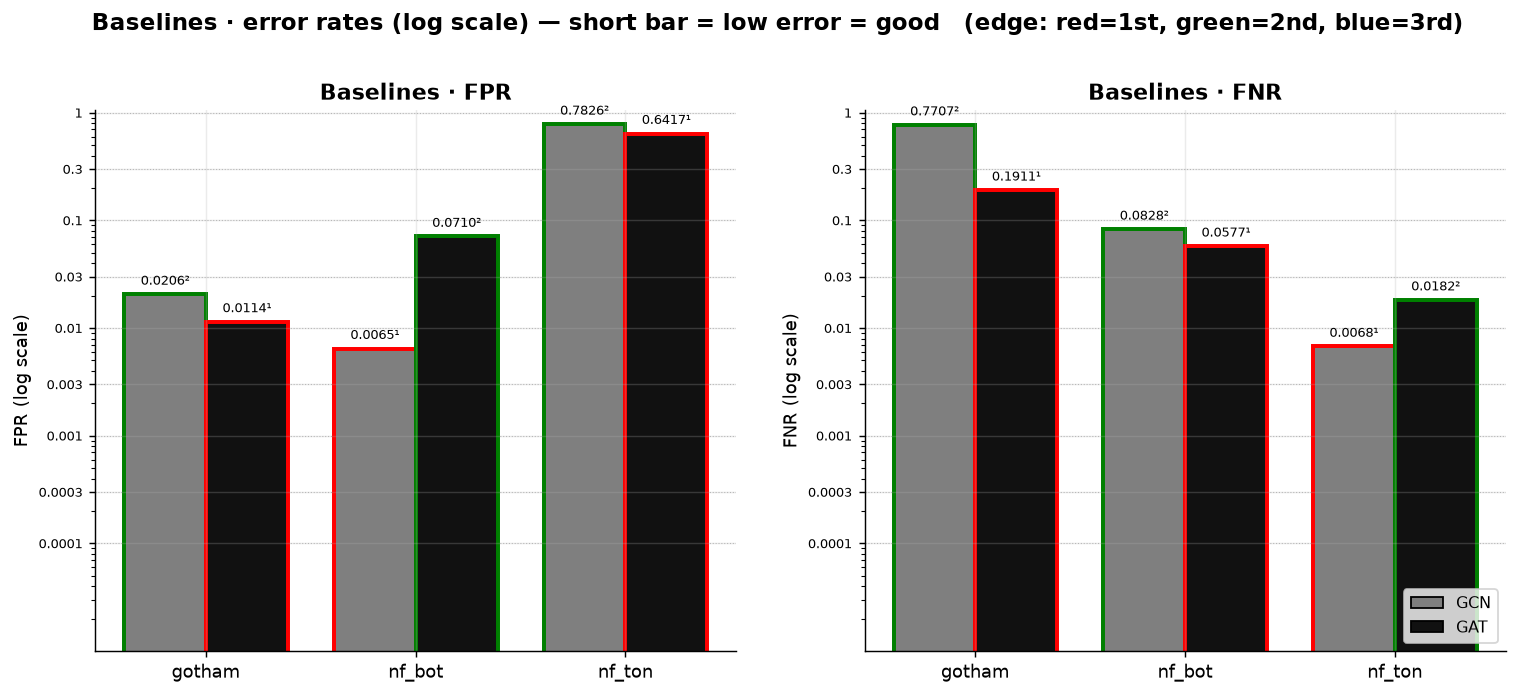

[save] plots/separated/baselines\error_rates.png
[baselines] done → plots/separated/baselines


In [5]:
SUB = f'{SEP_DIR}/baselines'
bdf = df[df['phase'] == 'Baseline']
if bdf.empty:
    print("[skip] no baseline rows")
else:
    methods = [m for m in METHOD_ORDER if m in bdf['method'].unique()]
    x = np.arange(len(DATASETS))
    w = 0.78 / max(len(methods), 1)

    # ---- ROC ----
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for i, m in enumerate(methods):
        vals = [bdf[(bdf['dataset']==d) & (bdf['method']==m)]['ROC'].max() for d in DATASETS]
        bars = ax.bar(x + (i - (len(methods)-1)/2)*w, vals, w, label=m,
                      color=_color(m), edgecolor='black', linewidth=0.4)
        rank_of = dict(_rank_indices(vals, 'max'))
        for k, (b, v) in enumerate(zip(bars, vals)):
            if np.isfinite(v):
                suffix = _rank_suffix(rank_of[k]) if k in rank_of else ''
                ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.3f}{suffix}",
                        ha='center', va='bottom', fontsize=7, rotation=90)
            if k in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[k]]); b.set_linewidth(2.2)
    ax.set_xticks(x); ax.set_xticklabels(DATASETS)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Test ROC')
    ax.set_title('Baselines · Test ROC   (edge: red=1st, green=2nd, blue=3rd)')
    _legend_for(methods, ax, loc='lower right', fontsize=9)
    _save(fig, 'roc_per_dataset.png', SUB)

    # ---- F1 ----
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for i, m in enumerate(methods):
        vals = [bdf[(bdf['dataset']==d) & (bdf['method']==m)]['F1'].max() for d in DATASETS]
        bars = ax.bar(x + (i - (len(methods)-1)/2)*w, vals, w, label=m,
                      color=_color(m), edgecolor='black', linewidth=0.4)
        rank_of = dict(_rank_indices(vals, 'max'))
        for k, (b, v) in enumerate(zip(bars, vals)):
            if np.isfinite(v):
                suffix = _rank_suffix(rank_of[k]) if k in rank_of else ''
                ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.3f}{suffix}",
                        ha='center', va='bottom', fontsize=7, rotation=90)
            if k in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[k]]); b.set_linewidth(2.2)
    ax.set_xticks(x); ax.set_xticklabels(DATASETS)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Test F1')
    ax.set_title('Baselines · Test F1   (edge: red=1st, green=2nd, blue=3rd)')
    _legend_for(methods, ax, loc='lower right', fontsize=9)
    _save(fig, 'f1_per_dataset.png', SUB)

    # ---- LOG-scale error rates ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
    for ax, metric in [(axes[0], 'FPR'), (axes[1], 'FNR')]:
        # Build a per-dataset rank map so we can highlight top-3 for each dataset
        ranks_per_ds = {}
        for d in DATASETS:
            dv = np.array([bdf[(bdf['dataset']==d) & (bdf['method']==m)][metric].max()
                           for m in methods], float)
            ranks_per_ds[d] = dict(_rank_indices(dv, 'min'))
        for i, m in enumerate(methods):
            _raw_vals = np.array(
                [bdf[(bdf['dataset']==d) & (bdf['method']==m)][metric].max()
                 for d in DATASETS], float)
            plot_vals = np.where(np.isfinite(_raw_vals),
                                 np.clip(_raw_vals, ERR_FLOOR, ERR_TOP),
                                 np.nan)
            off  = (i - (len(methods)-1)/2) * w
            bars = ax.bar(x + off, plot_vals, w, label=m, color=_color(m),
                          edgecolor='black', linewidth=0.4)
            for k, (b, v) in enumerate(zip(bars, _raw_vals)):
                d = DATASETS[k]
                rk = ranks_per_ds[d].get(i)
                suffix = _rank_suffix(rk) if rk is not None else ''
                _place_err_label(ax, b, v, INVERT_Y, suffix=suffix)
                if rk is not None:
                    b.set_edgecolor(RANK_COLORS[rk]); b.set_linewidth(2.2)
        _log_error_axis(ax)
        ax.set_xticks(x); ax.set_xticklabels(DATASETS)
        ax.set_ylabel(f'{metric} (log scale)')
        ax.set_title(f'Baselines · {metric}')
    _legend_for(methods, axes[1], loc='lower right', fontsize=9)
    note = ("short bar = low error = good" if not INVERT_Y else "axis inverted")
    fig.suptitle(f'Baselines · error rates (log scale) — {note}   '
                 f'(edge: red=1st, green=2nd, blue=3rd)',
                 y=1.02, fontsize=13, fontweight='bold')
    _save(fig, 'error_rates.png', SUB)
    print(f"[baselines] done → {SUB}")

## Cell 6 — SEPARATED · BYOL / MoCo probes

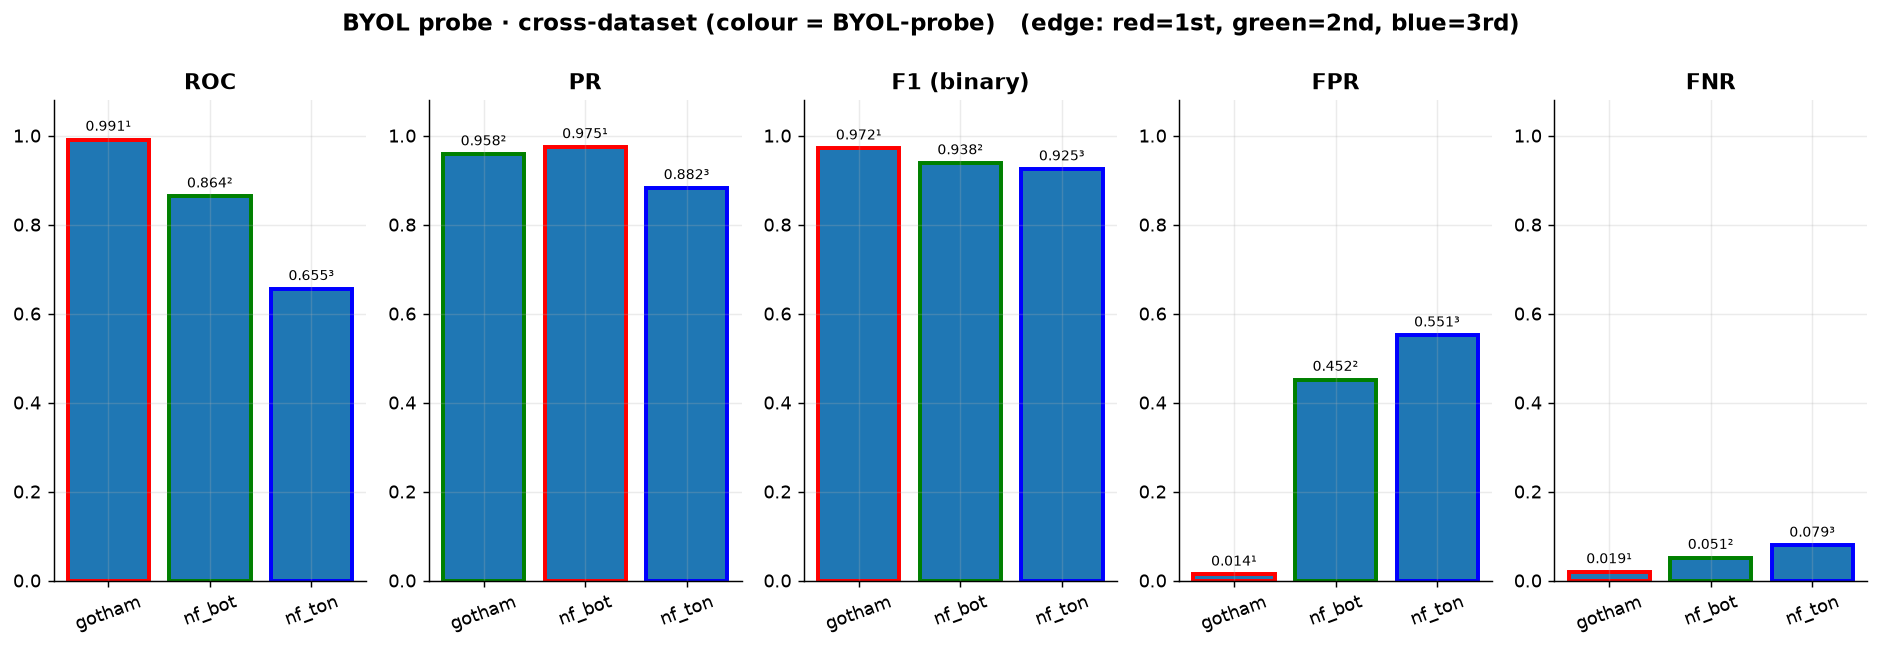

[save] plots/separated/ssl_byol\cross_dataset.png


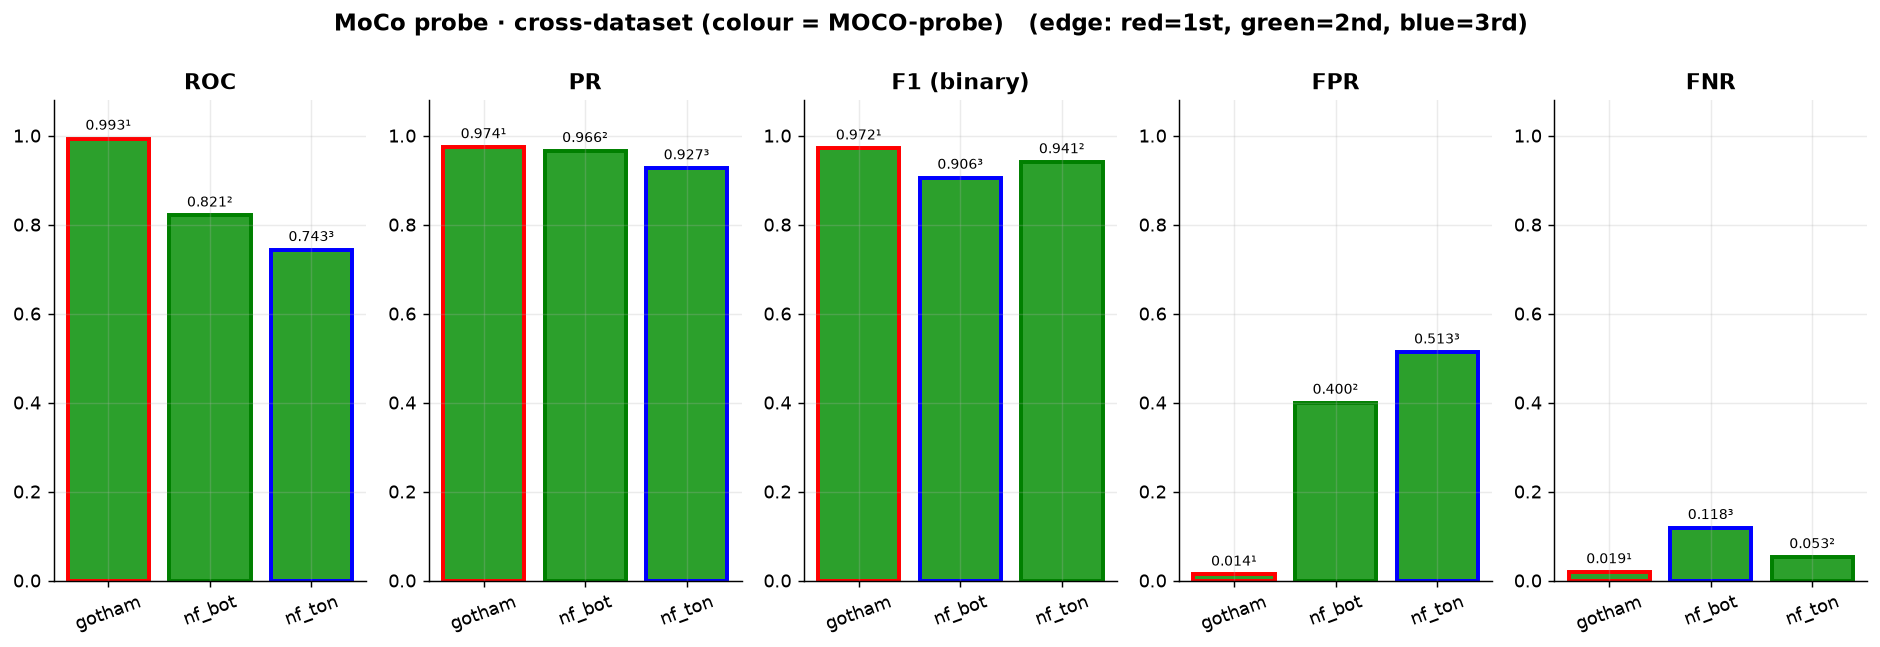

[save] plots/separated/ssl_moco\cross_dataset.png


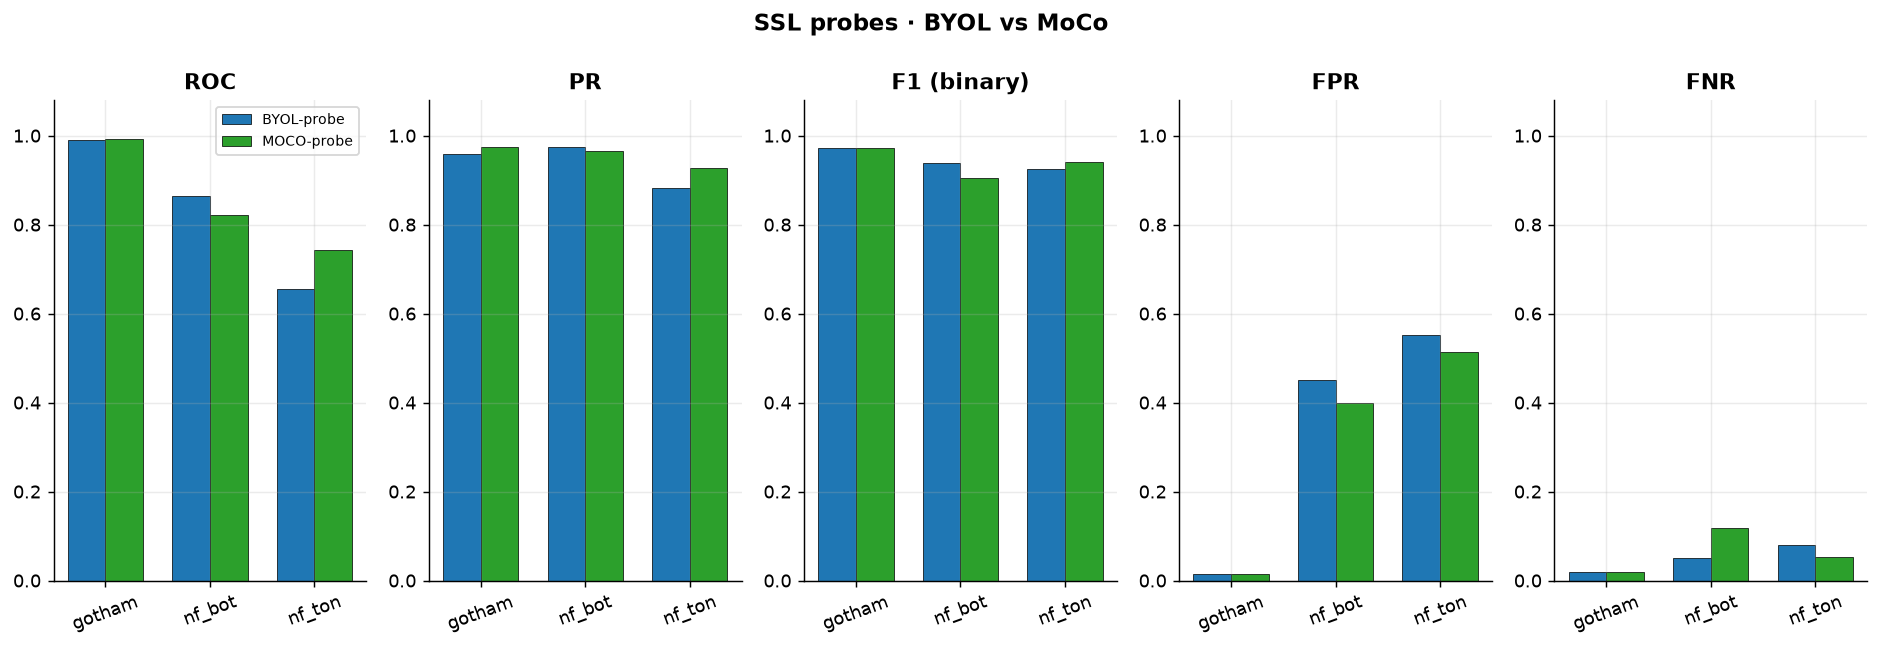

[save] plots/separated/ssl_compare\byol_vs_moco.png
[ssl_compare] done


In [6]:
METRICS = [('ROC','ROC'),('PR','PR'),('F1','F1 (binary)'),('FPR','FPR'),('FNR','FNR')]

def _ssl_bars(phase_name, folder):
    sub = df[df['phase'] == phase_name]
    if sub.empty:
        print(f"[skip] no rows for {phase_name}"); return
    mth = sub['method'].unique()[0]
    fig, axes = plt.subplots(1, len(METRICS), figsize=(3.6*len(METRICS), 4.8))
    x = np.arange(len(DATASETS))
    for ax, (metric, lbl) in zip(axes, METRICS):
        vals = [sub[sub['dataset']==d][metric].max() for d in DATASETS]
        bars = ax.bar(x, vals, color=_color(mth), edgecolor='black', linewidth=0.4)
        # Ranks are only meaningful within a single method across datasets
        mode = 'min' if metric in ('FPR','FNR') else 'max'
        rank_of = dict(_rank_indices(vals, mode))
        for k, (b, v) in enumerate(zip(bars, vals)):
            if np.isfinite(v):
                suffix = _rank_suffix(rank_of[k]) if k in rank_of else ''
                ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.3f}{suffix}",
                        ha='center', va='bottom', fontsize=8)
            if k in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[k]]); b.set_linewidth(2.2)
        ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=20)
        ax.set_ylim(0, 1.08); ax.set_title(lbl)
    fig.suptitle(f'{phase_name} · cross-dataset (colour = {mth})   '
                 f'(edge: red=1st, green=2nd, blue=3rd)',
                 y=1.02, fontsize=13, fontweight='bold')
    _save(fig, 'cross_dataset.png', folder)

_ssl_bars('BYOL probe', f'{SEP_DIR}/ssl_byol')
_ssl_bars('MoCo probe', f'{SEP_DIR}/ssl_moco')

sub = df[df['phase'].isin(['BYOL probe','MoCo probe'])]
if not sub.empty:
    fig, axes = plt.subplots(1, len(METRICS), figsize=(3.6*len(METRICS), 4.8))
    x = np.arange(len(DATASETS)); w = 0.36
    for ax, (metric, lbl) in zip(axes, METRICS):
        for i, (ph, mth) in enumerate([('BYOL probe','BYOL-probe'),
                                        ('MoCo probe','MOCO-probe')]):
            s = sub[sub['phase']==ph]
            vals = [s[s['dataset']==d][metric].max() for d in DATASETS]
            ax.bar(x + (i-0.5)*w, vals, w, label=mth, color=_color(mth),
                   edgecolor='black', linewidth=0.4)
        ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=20)
        ax.set_ylim(0, 1.08); ax.set_title(lbl)
    axes[0].legend(fontsize=8)
    fig.suptitle('SSL probes · BYOL vs MoCo', y=1.02, fontsize=13, fontweight='bold')
    _save(fig, 'byol_vs_moco.png', f'{SEP_DIR}/ssl_compare')
    print(f"[ssl_compare] done")

## Cell 7 — SEPARATED · TFT single vs ensemble

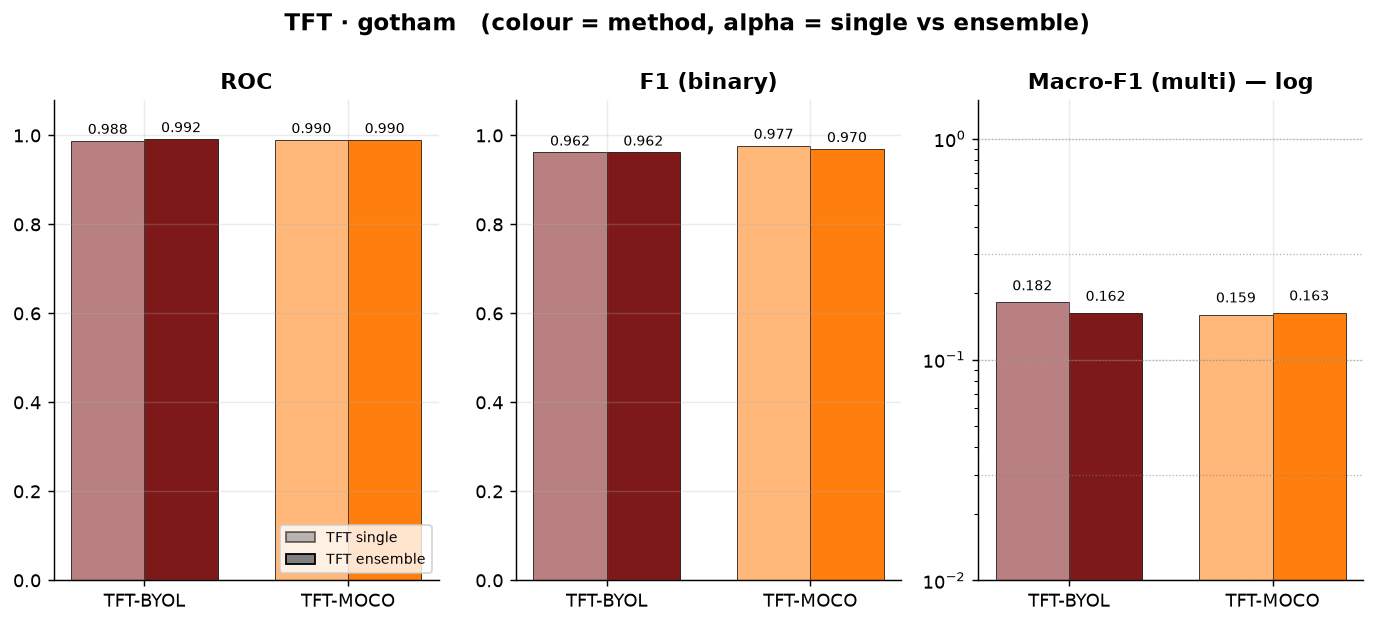

[save] plots/separated/tft\gotham_single_vs_ensemble.png


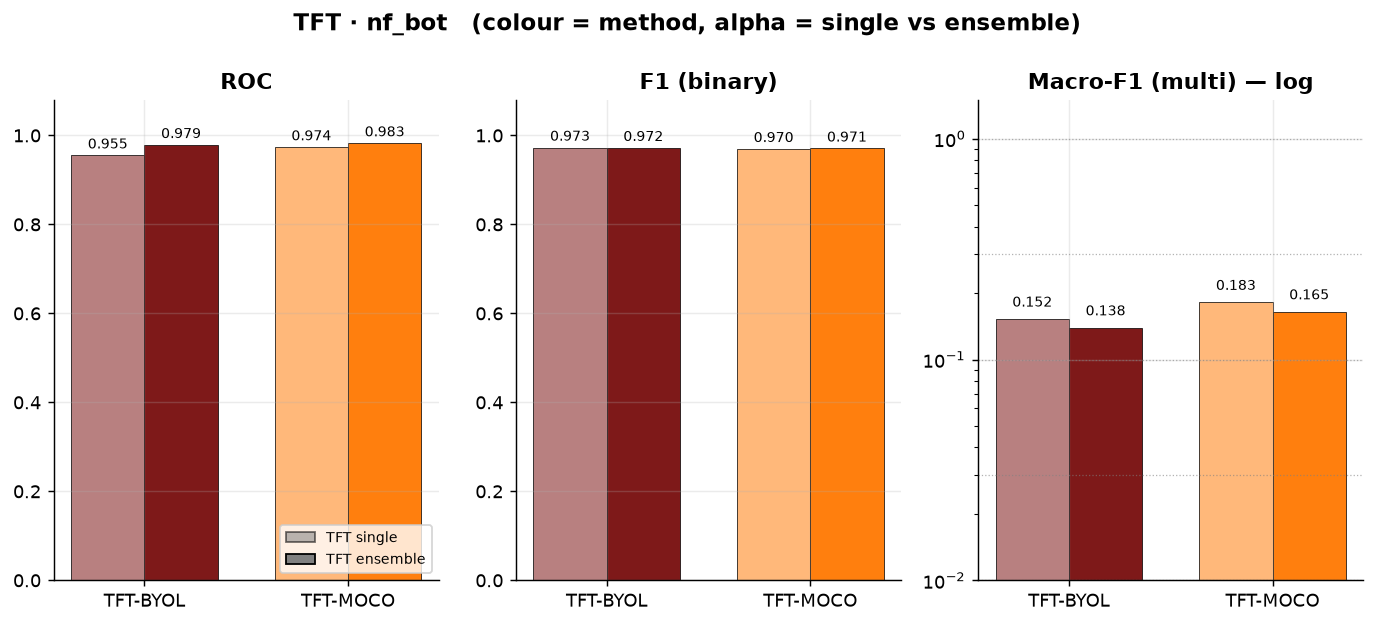

[save] plots/separated/tft\nf_bot_single_vs_ensemble.png


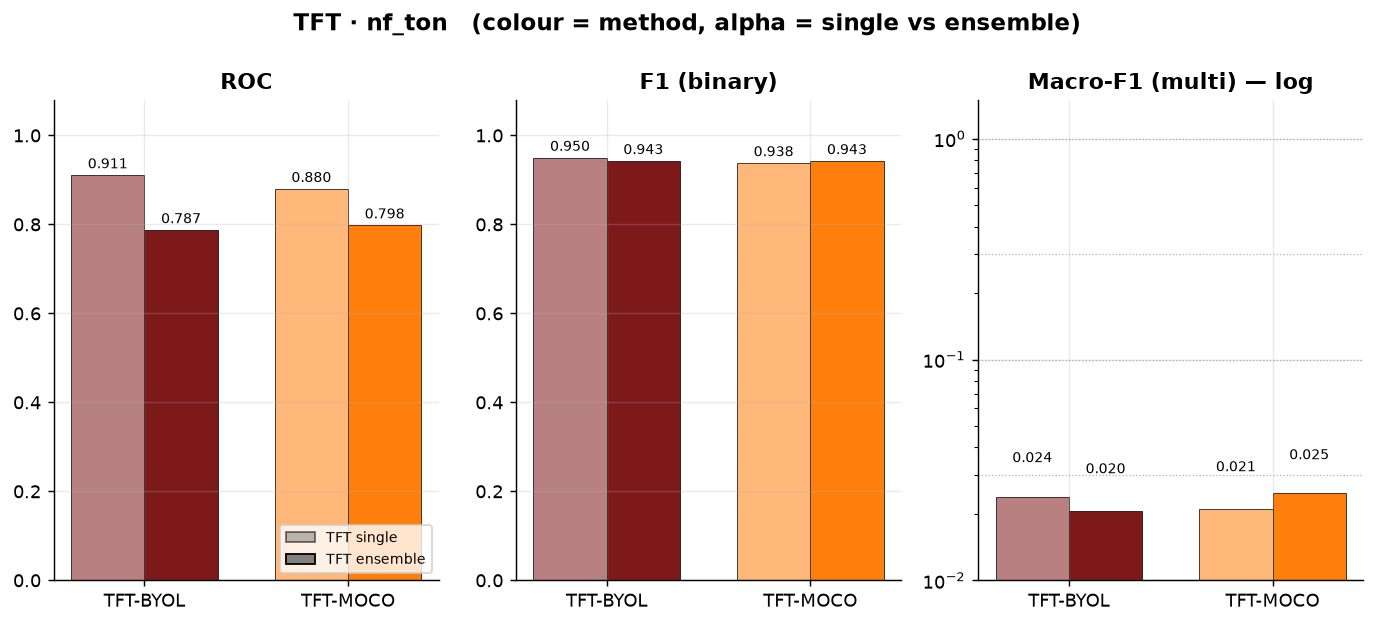

[save] plots/separated/tft\nf_ton_single_vs_ensemble.png
[tft] done → plots/separated/tft


In [7]:
SUB = f'{SEP_DIR}/tft'
tft = df[df['phase'].isin(['TFT single','TFT ensemble'])]
if tft.empty:
    print("[skip] no TFT rows")
else:
    tft_methods = ['TFT-BYOL', 'TFT-MOCO']
    for ds in DATASETS:
        s = tft[tft['dataset']==ds]
        if s.empty: continue
        fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
        for ax, metric, lbl, log_axis in [
                (axes[0], 'ROC', 'ROC', False),
                (axes[1], 'F1', 'F1 (binary)', False),
                (axes[2], 'mF1_multi', 'Macro-F1 (multi) — log', True)]:
            x = np.arange(len(tft_methods)); w = 0.36
            for i, ph in enumerate(['TFT single', 'TFT ensemble']):
                alphas = [0.55, 1.0]
                vals = [s[(s['method']==m) & (s['phase']==ph)][metric].max() for m in tft_methods]
                cols = [(*matplotlib.colors.to_rgb(_color(m)), alphas[i]) for m in tft_methods]
                bars = ax.bar(x + (i-0.5)*w, vals, w, color=cols,
                              edgecolor='black', linewidth=0.4, label=ph)
                for b, v in zip(bars, vals):
                    if np.isfinite(v):
                        ax.text(b.get_x()+b.get_width()/2,
                                v*(1.05 if log_axis else 1.0)+0.008,
                                f"{v:.3f}", ha='center', va='bottom', fontsize=7.5)
            ax.set_xticks(x); ax.set_xticklabels(tft_methods)
            ax.set_title(lbl)
            if log_axis:
                ax.set_yscale('log'); ax.set_ylim(0.01, 1.5)
                for y in [0.01, 0.03, 0.10, 0.30, 1.00]:
                    ax.axhline(y, color='grey', ls=':', lw=0.7, alpha=0.6)
            else:
                ax.set_ylim(0, 1.08)
        handles = [Patch(facecolor='grey', alpha=0.55, edgecolor='black', label='TFT single'),
                   Patch(facecolor='grey', alpha=1.00, edgecolor='black', label='TFT ensemble')]
        axes[0].legend(handles=handles, fontsize=8, loc='lower right')
        fig.suptitle(f'TFT · {ds}   (colour = method, alpha = single vs ensemble)',
                     y=1.02, fontsize=13, fontweight='bold')
        _save(fig, f'{ds}_single_vs_ensemble.png', SUB)
    print(f"[tft] done → {SUB}")

## Cell 8 — SEPARATED · Attention

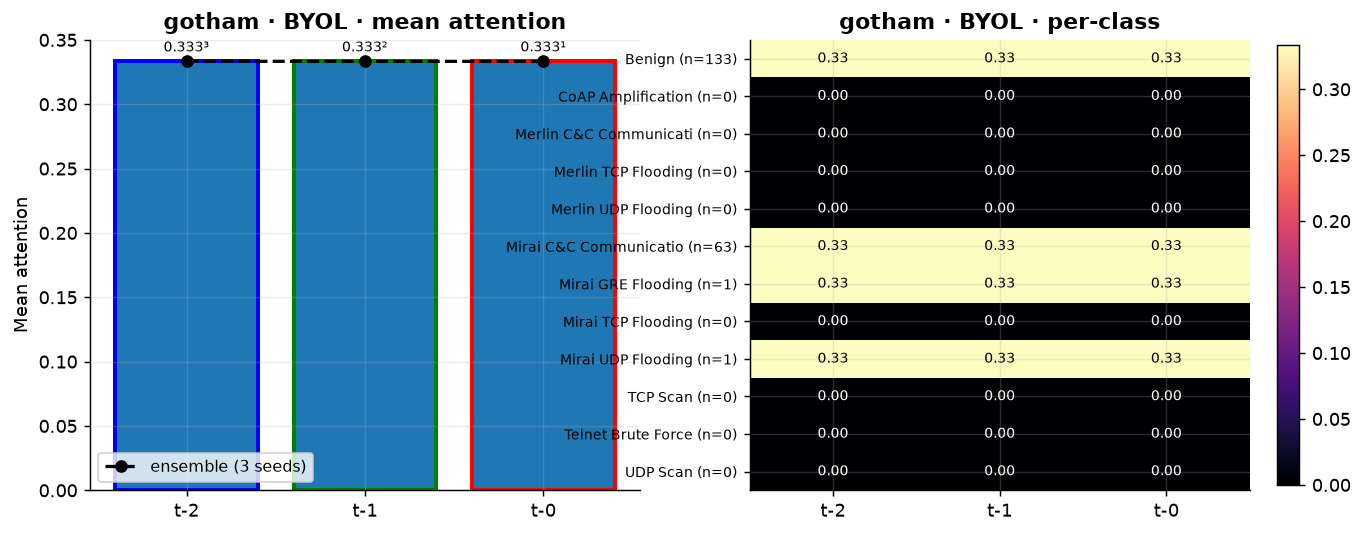

[save] plots/separated/attention\gotham_byol_attention.png


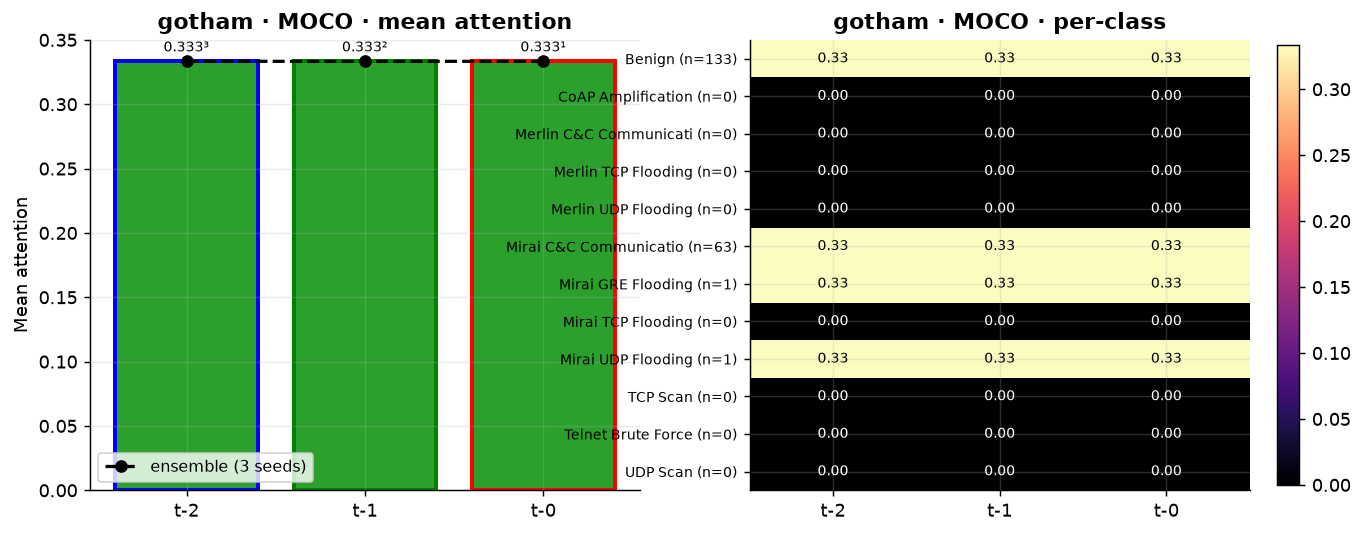

[save] plots/separated/attention\gotham_moco_attention.png


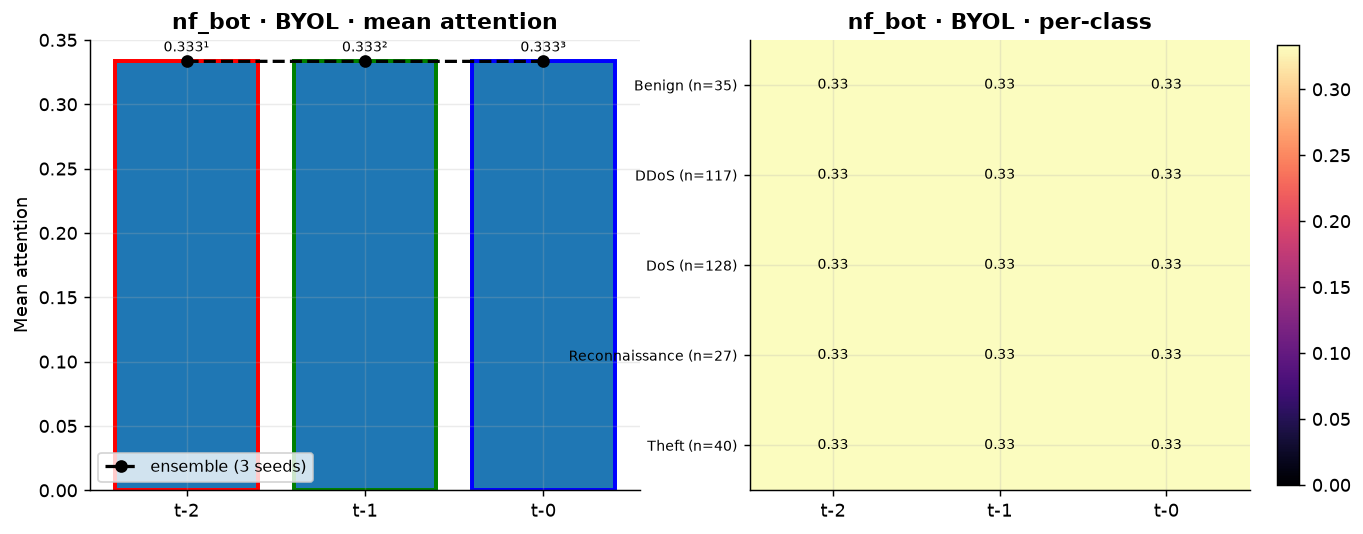

[save] plots/separated/attention\nf_bot_byol_attention.png


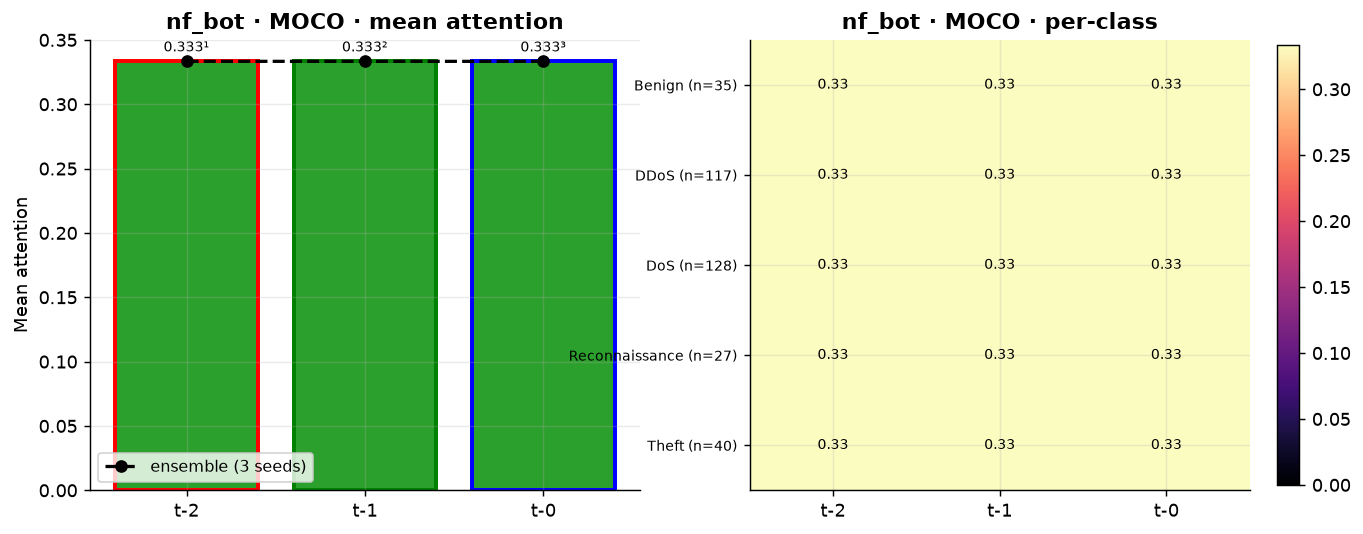

[save] plots/separated/attention\nf_bot_moco_attention.png


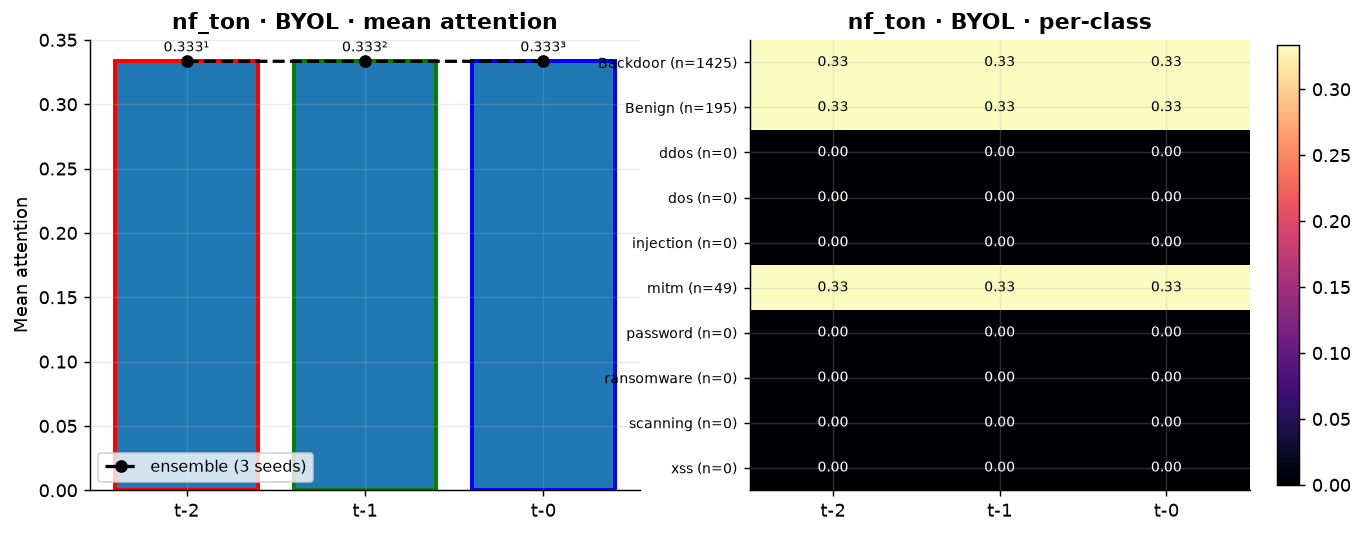

[save] plots/separated/attention\nf_ton_byol_attention.png


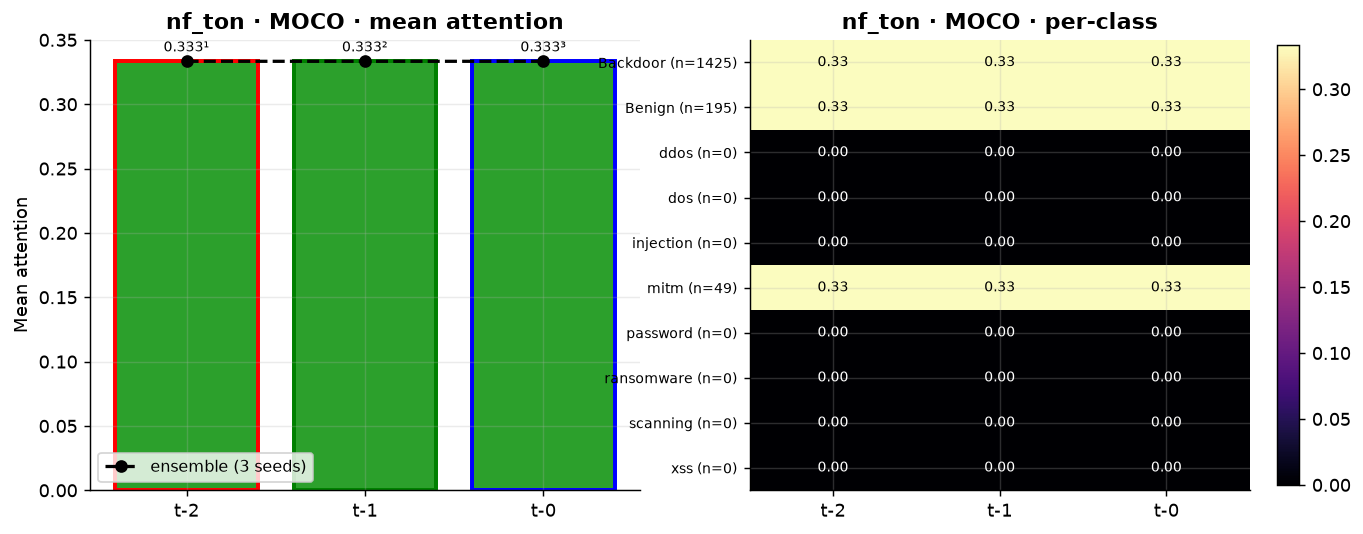

[save] plots/separated/attention\nf_ton_moco_attention.png


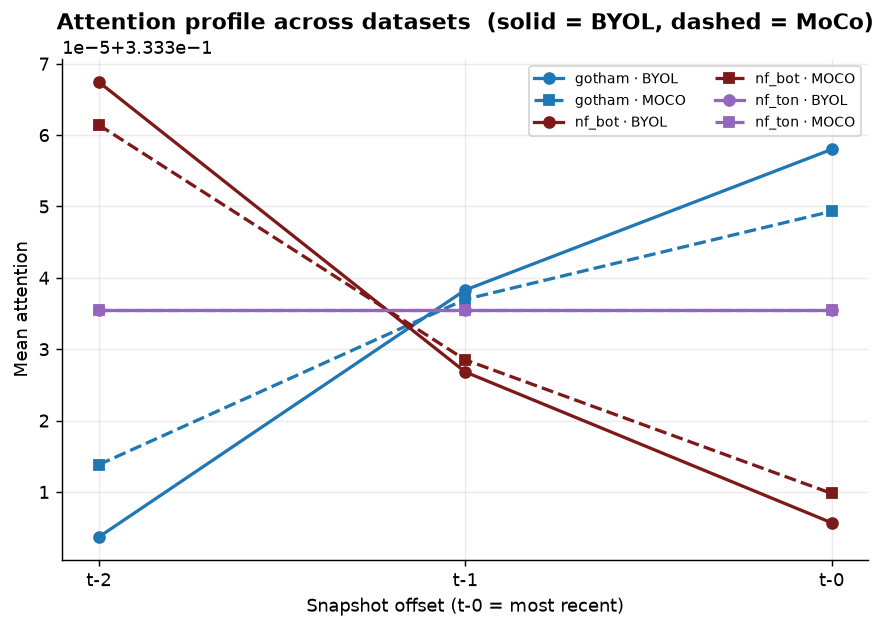

[save] plots/separated/attention\cross_dataset_profile.png
[attention] done → plots/separated/attention


In [8]:
SUB = f'{SEP_DIR}/attention'

# reload raw (defensive against earlier cells overwriting `raw`)
raw = _load_json('phase3_all_results_raw.json') or {}
if raw and not set(raw.keys()).issubset({'byol', 'moco'}):
    by_ssl = {'byol': {}, 'moco': {}}
    for ds, per in raw.items():
        if isinstance(per, dict):
            for ssl, r in per.items():
                by_ssl.setdefault(ssl.lower(), {})[ds] = r
    raw = by_ssl

def _attn_dir(ds, ssl):
    try:
        cand = raw[ssl][ds]['attention']['attn_dir']
        if isinstance(cand, str) and os.path.isdir(cand):
            return cand
    except (KeyError, TypeError, IndexError):
        pass
    fallback = os.path.join(DATA_DIRS.get(ds, ''),
                            f'phase3_checkpoints_{ssl}_finetune', 'attention')
    return fallback if os.path.isdir(fallback) else None

ATTN = {}
for ds in DATASETS:
    ATTN[ds] = {}
    for ssl in SSL_LIST:
        ad = _attn_dir(ds, ssl)
        if ad is None: continue
        p_mean = os.path.join(ad, 'mean_attention.npy')
        p_pcl  = os.path.join(ad, 'per_class_attention.npy')
        p_ens  = os.path.join(ad, 'ensemble_mean_attention.npy')
        ATTN[ds][ssl] = dict(
            mean=np.load(p_mean) if os.path.isfile(p_mean) else None,
            per_class=np.load(p_pcl) if os.path.isfile(p_pcl) else None,
            ens=np.load(p_ens) if os.path.isfile(p_ens) else None,
            meta=_load_json(os.path.join(ad, 'class_names.json')),
        )

SSL_COLOR = {'byol': _color('BYOL-probe'), 'moco': _color('MOCO-probe')}

for ds, per in ATTN.items():
    for ssl, a in per.items():
        if a['mean'] is None: continue
        T = len(a['mean']); xs = np.arange(T)
        labels = [f"t-{T-1-i}" for i in range(T)]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        axes[0].bar(xs, a['mean'], color=SSL_COLOR[ssl],
                    edgecolor='black', linewidth=0.4)
        # Top-3 timesteps by mean attention
        rank_of = dict(_rank_indices(a['mean'], 'max'))
        for b, v, k in zip(axes[0].patches, a['mean'], range(T)):
            suffix = _rank_suffix(rank_of[k]) if k in rank_of else ''
            axes[0].text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}{suffix}",
                         ha='center', va='bottom', fontsize=8)
            if k in rank_of:
                b.set_edgecolor(RANK_COLORS[rank_of[k]]); b.set_linewidth(2.2)
        if a['ens'] is not None and len(a['ens']) == T:
            axes[0].plot(xs, a['ens'], 'o--', color='black', lw=1.8, ms=6,
                         label='ensemble (3 seeds)')
            axes[0].legend(fontsize=9)
        axes[0].set_xticks(xs); axes[0].set_xticklabels(labels)
        axes[0].set_ylabel('Mean attention')
        axes[0].set_title(f'{ds} · {ssl.upper()} · mean attention')

        if a['per_class'] is not None and a['meta'] is not None:
            pc = a['per_class']; names = a['meta']['class_names']
            counts = a['meta'].get('class_counts', [0]*len(names))
            vmax = float(pc.max()) if pc.size else 1.0
            im = axes[1].imshow(pc, aspect='auto', cmap='magma',
                                vmin=0, vmax=max(vmax, 0.01))
            axes[1].set_xticks(xs); axes[1].set_xticklabels(labels)
            axes[1].set_yticks(np.arange(len(names)))
            axes[1].set_yticklabels([f"{n[:22]} (n={c})" for n, c in zip(names, counts)], fontsize=8)
            for i in range(pc.shape[0]):
                for j in range(pc.shape[1]):
                    v = pc[i, j]
                    axes[1].text(j, i, f"{v:.2f}", ha='center', va='center',
                                 color='white' if v < 0.55*vmax else 'black', fontsize=8)
            axes[1].set_title(f'{ds} · {ssl.upper()} · per-class')
            plt.colorbar(im, ax=axes[1], fraction=0.04)
        else:
            axes[1].axis('off')
        _save(fig, f'{ds}_{ssl}_attention.png', SUB)

if any(ATTN[d] for d in ATTN):
    palette = {'gotham':'#1f77b4','nf_bot':'#7e1919','nf_ton':'#9467bd'}
    fig, ax = plt.subplots(figsize=(8, 5))
    for ds, per in ATTN.items():
        for ssl, a in per.items():
            if a['mean'] is None: continue
            T = len(a['mean'])
            ax.plot(np.arange(T), a['mean'], '-' if ssl=='byol' else '--',
                    marker='o' if ssl=='byol' else 's', lw=1.8, ms=6,
                    color=palette.get(ds, '#555'), label=f'{ds} · {ssl.upper()}')
    ax.set_xticks(np.arange(3)); ax.set_xticklabels(['t-2','t-1','t-0'])
    ax.set_xlabel('Snapshot offset (t-0 = most recent)')
    ax.set_ylabel('Mean attention')
    ax.set_title('Attention profile across datasets  (solid = BYOL, dashed = MoCo)')
    ax.legend(fontsize=8, ncol=2)
    _save(fig, 'cross_dataset_profile.png', SUB)
    print(f"[attention] done → {SUB}")

## Cell 9 — SEPARATED · Few-shot

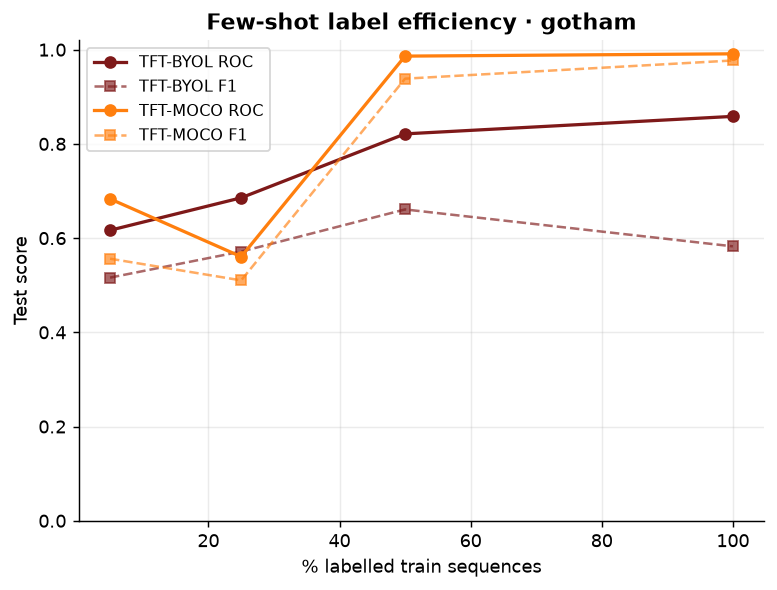

[save] plots/separated/fewshot\gotham_fewshot.png


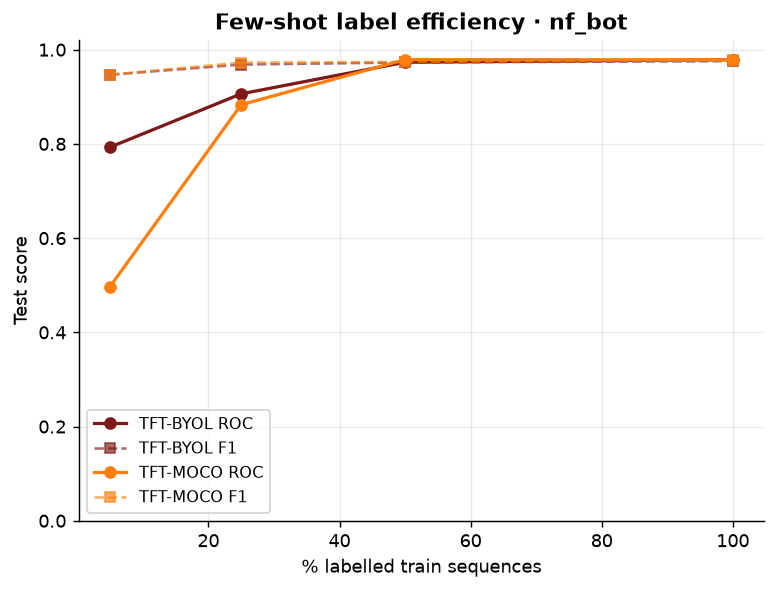

[save] plots/separated/fewshot\nf_bot_fewshot.png


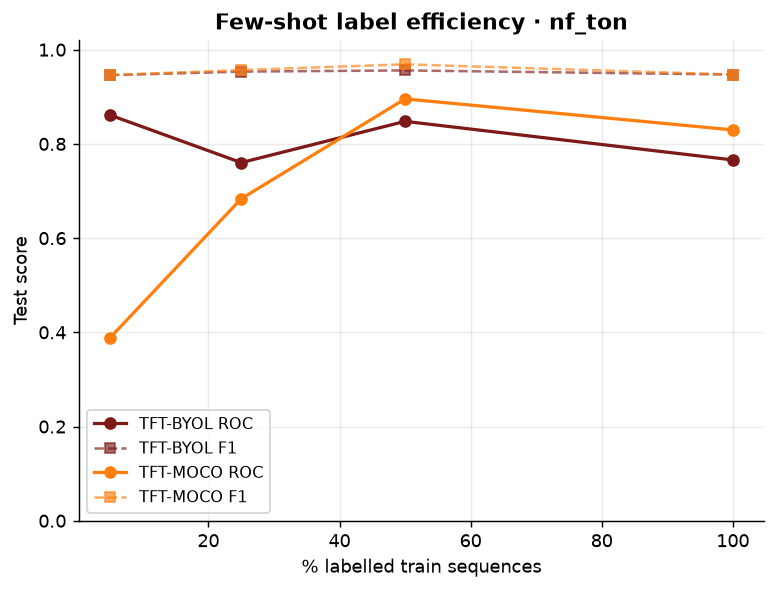

[save] plots/separated/fewshot\nf_ton_fewshot.png
[fewshot] 3 figures → plots/separated/fewshot


In [9]:
SUB = f'{SEP_DIR}/fewshot'

# defensive reload
raw = _load_json('phase3_all_results_raw.json') or {}
if raw and not set(raw.keys()).issubset({'byol', 'moco'}):
    by_ssl = {'byol': {}, 'moco': {}}
    for ds, per in raw.items():
        if isinstance(per, dict):
            for ssl, r in per.items():
                by_ssl.setdefault(ssl.lower(), {})[ds] = r
    raw = by_ssl

if not raw:
    print("[skip] no TFT raw results")
else:
    plotted = 0
    for ds in DATASETS:
        fig, ax = plt.subplots(figsize=(6.8, 4.8))
        any_plotted = False
        for ssl in ['byol', 'moco']:
            col = _color(f'TFT-{ssl.upper()}')
            r = raw.get(ssl, {}).get(ds, {})
            fs = r.get('fewshot', {}) if isinstance(r, dict) else {}
            if not fs: continue
            try:
                keys = sorted(fs.keys(), key=lambda z: float(z))
            except Exception:
                continue
            xs   = [float(k) * 100 for k in keys]
            rocs = [fs[k].get('test_roc', np.nan) for k in keys]
            f1s  = [fs[k].get('test_f1',  np.nan) for k in keys]
            ax.plot(xs, rocs, 'o-', lw=1.8, color=col, label=f'TFT-{ssl.upper()} ROC')
            ax.plot(xs, f1s,  's--', lw=1.4, color=col, alpha=0.65,
                    label=f'TFT-{ssl.upper()} F1')
            any_plotted = True
        if not any_plotted:
            plt.close(fig); continue
        ax.set_xlabel('% labelled train sequences')
        ax.set_ylabel('Test score')
        ax.set_ylim(0.0, 1.02)
        ax.set_title(f'Few-shot label efficiency · {ds}')
        ax.legend(fontsize=9)
        _save(fig, f'{ds}_fewshot.png', SUB)
        plotted += 1
    print(f"[fewshot] {plotted} figures → {SUB}")

## Cell 10 — SEPARATED · Per-attack-class ROC

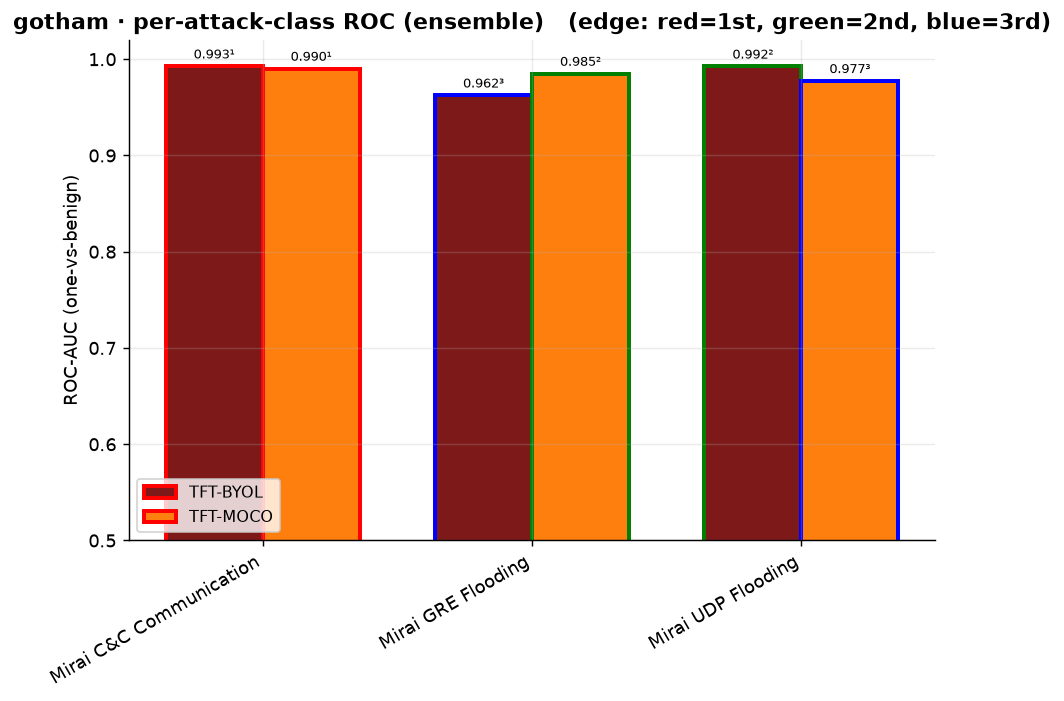

[save] plots/separated/per_class\gotham_per_class_ROC.png


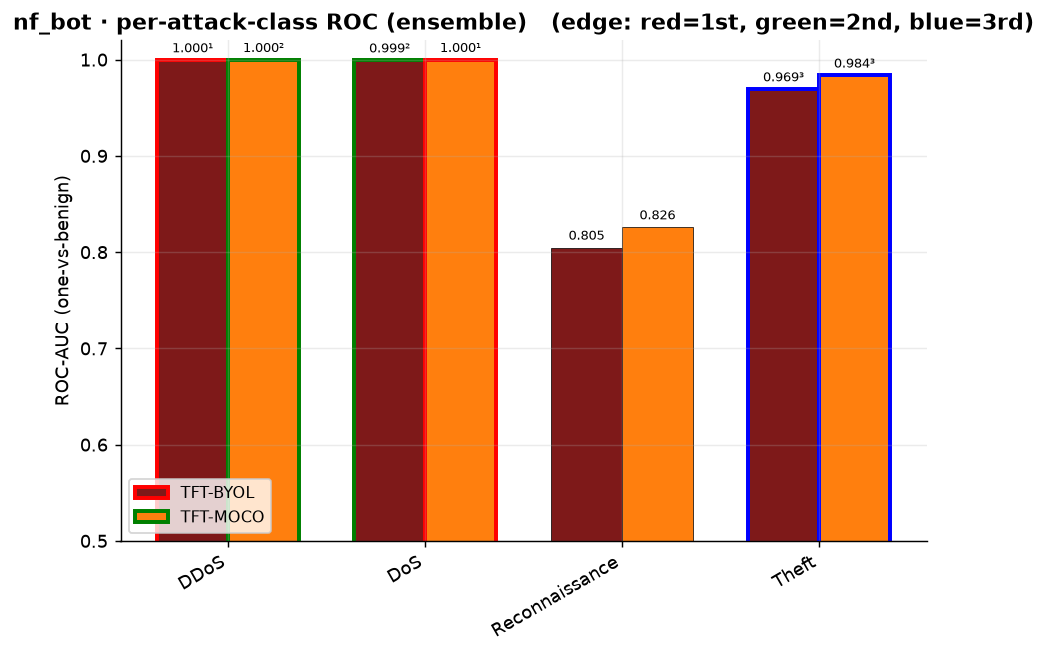

[save] plots/separated/per_class\nf_bot_per_class_ROC.png


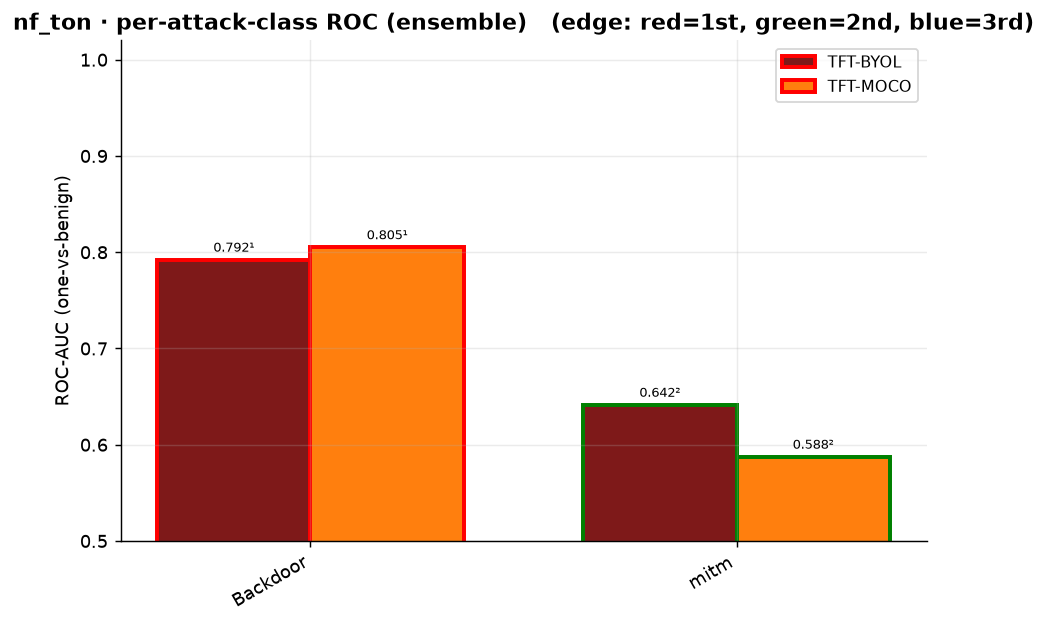

[save] plots/separated/per_class\nf_ton_per_class_ROC.png
[per_class] 3 figures → plots/separated/per_class


In [10]:
SUB = f'{SEP_DIR}/per_class'

# defensive reload
raw = _load_json('phase3_all_results_raw.json') or {}
if raw and not set(raw.keys()).issubset({'byol', 'moco'}):
    by_ssl = {'byol': {}, 'moco': {}}
    for ds, per in raw.items():
        if isinstance(per, dict):
            for ssl, r in per.items():
                by_ssl.setdefault(ssl.lower(), {})[ds] = r
    raw = by_ssl

if not raw:
    print("[skip] no TFT raw results")
else:
    count = 0
    for ds in DATASETS:
        by_class = {}
        for ssl in SSL_LIST:
            r = raw.get(ssl, {}).get(ds, {})
            rows_c = r.get('per_class_ensemble', []) if isinstance(r, dict) else []
            for row in rows_c:
                by_class.setdefault(row['class'], {})[ssl] = row
        classes = sorted(by_class.keys())
        if not classes: continue
        fig, ax = plt.subplots(figsize=(max(8, len(classes)*1.4), 5))
        x = np.arange(len(classes)); w = 0.36
        for i, ssl in enumerate(['byol', 'moco']):
            col = _color(f'TFT-{ssl.upper()}')
            vals = [by_class[c].get(ssl, {}).get('roc_vs_benign', np.nan) for c in classes]
            bars = ax.bar(x + (i-0.5)*w, vals, w, label=f'TFT-{ssl.upper()}', color=col,
                          edgecolor='black', linewidth=0.4)
            rank_of = dict(_rank_indices(vals, 'max'))
            for k, (b, v) in enumerate(zip(bars, vals)):
                if np.isfinite(v):
                    suffix = _rank_suffix(rank_of[k]) if k in rank_of else ''
                    ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}{suffix}",
                            ha='center', va='bottom', fontsize=7)
                if k in rank_of:
                    b.set_edgecolor(RANK_COLORS[rank_of[k]]); b.set_linewidth(2.2)
        ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha='right')
        ax.set_ylim(0.5, 1.02); ax.set_ylabel('ROC-AUC (one-vs-benign)')
        ax.set_title(f'{ds} · per-attack-class ROC (ensemble)   '
                     f'(edge: red=1st, green=2nd, blue=3rd)')
        ax.legend(fontsize=9)
        _save(fig, f'{ds}_per_class_ROC.png', SUB)
        count += 1
    print(f"[per_class] {count} figures → {SUB}")

## Cell 11 — Final listing

In [14]:
def _tree(root):
    for dirpath, _, files in os.walk(root):
        rel = os.path.relpath(dirpath, root)
        print(f"{rel}/")
        for f in sorted(files):
            sz = os.path.getsize(os.path.join(dirpath, f)) / 1024
            print(f"   {f:<48} ({sz:6.1f} KB)")

print('=' * 70)
print('UNIFIED → ' + os.path.abspath(COMPARE_DIR))
print('=' * 70)
_tree(COMPARE_DIR)
print()
print('=' * 70)
print('SEPARATED → ' + os.path.abspath(SEP_DIR))
print('=' * 70)
_tree(SEP_DIR)

UNIFIED → c:\Users\User\Desktop\MC-STGAT-IDS\MC-STGAT-IDS-V3\plots\compare
./
   01_headline_ROC.png                              (  90.1 KB)
   02_headline_F1.png                               (  89.2 KB)
   03_error_rates.png                               ( 198.8 KB)
   04_macroF1_multi.png                             (  86.1 KB)
   05_heatmap_ROC.png                               (  67.0 KB)
   06_heatmap_F1.png                                (  68.5 KB)
   07_ensemble_vs_single.png                        (  58.8 KB)
   winner_per_dataset.csv                           (   0.3 KB)

SEPARATED → c:\Users\User\Desktop\MC-STGAT-IDS\MC-STGAT-IDS-V3\plots\separated
./
attention/
   cross_dataset_profile.png                        (  93.9 KB)
   gotham_byol_attention.png                        ( 115.6 KB)
   gotham_moco_attention.png                        ( 113.4 KB)
   nf_bot_byol_attention.png                        (  75.8 KB)
   nf_bot_moco_attention.png                        (  75.0 